# Subsetting: the malignant compartment

From `shiao.h5ad` (619,693 x 30,869, phase 01) to a raw, re-filtered object holding only the
cells 05_1 found aneuploid.

- join the 05_1 call (`cnv_status.csv`) and re-annotation (`cell_annotation_cnv.csv`)
- subset on the **measurement**, not on a label: `cnv_status == 'malignant'`
- record the criterion in `compartment == 'tum'`, keep the pre-CNV label as `cell_type_01_4`
- recompute `fraction` from the post-CNV `cell_type` (it is a function of that column)
- restore `.X` = raw counts and drop every slot phase 01 computed on the full object
  (PCA, UMAP, neighbours, HVG flags, scran size factors, leiden columns, stale palettes)
- drop the categories left empty by the subset
- recompute the QC metrics, re-apply the cell thresholds, re-run the gene filter
- drop the cohorts left under 200 cells
- write `shiao_tum_raw.h5ad`, the input of `subsetting_all.sh`

Nothing is normalized here: scran runs in the next step, on this file, because its size factors
have to be estimated on the cells that remain.

This is 04_1 applied to a compartment 04 could not see. The epithelial compartment of 04 mixes
normal and malignant epithelium under labels that cannot tell them apart, so its HVGs, its PCA and
its DRVI dimensions describe that mixture; nothing of that phase is inherited here, the subset is
taken from `shiao.h5ad` again.

## The cell set

`CELL_SET` picks what gets subsetted. Set it before starting the kernel, or in the first code cell:

| `CELL_SET` | cells kept | prefix | role |
|---|---|---|---|
| `tum` (default) | `cnv_status == 'malignant'` | `shiao_tum` | the phase |
| `epi` | every epithelial cell under the post-CNV labels, malignant included, `not_tested` dropped | `shiao_epicnv` | a control |

The two write different files and never overwrite each other.

## Packages and paths

In [1]:
# Core scverse libraries
from __future__ import annotations

# Main
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import os
import sys

# Plotting
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import seaborn as sns

# Scanpy setting: clean white background and high resolution figures
sc.set_figure_params(dpi=300, facecolor='white')
# Set the level of verbosity of scanpy to get more detailed info
sc.settings.verbosity = 3

# CELL_SET has to be set before cell_set.py is asked anything. Change it here to run the
# control instead of the primary line.
os.environ.setdefault('CELL_SET', 'tum')
import importlib
import cell_set as C
# Reload on every run of this cell. cell_set.py is a sibling file that gets edited while the
# notebook is open, and Python caches modules in sys.modules: without this, an edit made after
# the first import stays invisible until the kernel is restarted, and the failure shows up much
# later as an AttributeError in the middle of a half-processed object.
importlib.reload(C)

PHASE_DIR = os.path.dirname(os.getcwd())  # 05_drvi_tumoral_epi/
REPO_ROOT = os.path.dirname(PHASE_DIR)

FIG_DIR = os.environ.get('FIG_DIR', os.path.join(PHASE_DIR, 'figures', '05_2_subset_and_qc'))
os.makedirs(FIG_DIR, exist_ok=True)
sc.settings.figdir = FIG_DIR

# One colour per cell set, used by every panel below. 04_1 drew its QC in tab:blue; this phase
# is about the tumour, so the malignant set gets a brick red - deep enough that the black jitter
# points stay readable on top of it, and muted enough not to fight the figure. The control set
# keeps a blue, because it is the same population 04 worked on.
SET_COLORS = {'tum': '#B03A2E', 'epi': '#4A6FA5'}
QC_COLOR = SET_COLORS[C.cell_set()]
# The word that goes into the figure titles, where 04 writes 'epithelial'.
SET_TITLES = {'tum': 'malignant', 'epi': 'epithelial (post-CNV)'}

# Tell Jupyter to show all outputs and not only the last one
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

print('cwd      :', os.getcwd())
print('REPO_ROOT:', REPO_ROOT)
print('FIG_DIR  :', FIG_DIR)
print('colour   :', QC_COLOR)

cwd      : /home/albertoc/Desktop/QCB-Master-Thesis/05_drvi_tumoral_epi/05_2_subsetting
REPO_ROOT: /home/albertoc/Desktop/QCB-Master-Thesis
FIG_DIR  : /home/albertoc/Desktop/QCB-Master-Thesis/05_drvi_tumoral_epi/figures/05_2_subset_and_qc
colour   : #B03A2E


Setup the directory of the data. This is the path to the cluster data folder (outside the repo) or
to the local data folder, like in this case. Raw and heavy intermediate objects live here; the repo
holds only code and lightweight QC figures.

Everything this phase produces goes in `05_tum/`, next to what 05_1 already wrote there, so the
malignant chain never gets confused with the epithelial one of 04.

In [2]:
DATA_DIR = os.environ.get('DATA_DIR', '').strip() or 'datasets'
DATA_DIR = os.path.abspath(os.path.join(REPO_ROOT, os.path.expanduser(DATA_DIR)))
os.environ['DATA_DIR'] = DATA_DIR  # absolute from now on: re-running this cell is a no-op

INPUT_H5AD = os.path.join(DATA_DIR, 'shiao.h5ad')
# Which 05_1 call this is built on is $CNV_TAG, resolved in cell_set.py and nowhere else.
# It defaults to 'newcnv': the per-subcluster call with the cohort gate, the stratified
# stromal null and the held-out immune control. CNV_TAG='' reproduces the original per-cell
# call, whose objects are kept under datasets/05_tum/objects_v1/.
STATUS_CSV = str(C.status_csv())
ANNOT_CSV = str(C.annot_csv())
OUTPUT_H5AD = str(C.path('_raw.h5ad'))

for path, produced_by in ((INPUT_H5AD, 'phase 01'),
                          (STATUS_CSV, '05_1/call_malignant_newcnv.ipynb'),
                          (ANNOT_CSV, '05_1/recelltypist_nonmalignant.py --tag newcnv')):
    if not os.path.exists(path):
        raise FileNotFoundError(f'missing {path}\n(produced by {produced_by}; run it first)')

C.banner('05_2 subset and QC')
print('Input :', INPUT_H5AD, f'({os.path.getsize(INPUT_H5AD) / 1024 ** 3:.2f} GB)')


05_2 subset and QC  |  CELL_SET=tum (the malignant cells)


DATA_DIR : /home/albertoc/Desktop/QCB-Master-Thesis/datasets


prefix   : shiao_tum


CNV_TAG  : newcnv  (cnv_status_newcnv.csv)


Input : /home/albertoc/Desktop/QCB-Master-Thesis/datasets/shiao.h5ad (4.41 GB)


## Parameters

The cell thresholds are the same as 01_2 and 04_1. This is the place to make the malignant
compartment stricter. They all live in [cell_set.py](cell_set.py), with the argument for each
next to it, because four scripts downstream read the same numbers.

| | value | same as 04_1? |
|---|---|---|
| `MIN_GENES` | 100 | yes |
| `MAX_PCT_MT` | 10 | yes |
| `MIN_CELLS` (gene filter) | 3 | yes |
| `MIN_CELLS_PER_COHORT` | 200 | yes |
| `DROP_INCOMPLETE_COHORTS` | **False** | **no** |

### What is *not* re-run, and why

**Scrublet.** Not re-run, for the reason 04_1 gives and one measured here. Doublet detection was
done per biopsy on the full object, where the mixture of lineages is what makes a doublet
detectable at all; re-running it inside a single lineage - let alone inside a single clone - would
be worse, not better. And empirically there is nothing to catch: of the 4,326 cells flagged
`predicted_doublet` in `shiao.h5ad`, **4** are in the malignant subset (0.00%) and 432 in the wider
`epi` set (0.07%). The flags are carried through as metadata either way.

> This is worth one more line because the `emt` collection names doublets as a risk: a
> tumour-plus-fibroblast doublet is exactly what a spurious 'hybrid' cell would look like. Two
> things guard that here rather than one - the flags above, and the subset itself, since a cell has
> to be aneuploid to be in this object and a fibroblast is not.

**`fraction_reassignment`.** Its *logic* is re-run, inline, but not its script. `fraction` is a pure
function of `cell_type` - a lookup against the immune lineage list, no model and no state - and this
phase replaces `cell_type` with the post-CNV label, which makes the inherited column stale on
arrival. `cell_set.reassign_fraction()` is that lookup. It changes nothing under `CELL_SET=tum`
(every malignant cell was epithelial, hence already `non_imm`) and it matters under `CELL_SET=epi`,
where the subset can pull in cells the 01_4 annotation had called immune.

**Cell cycle scoring, scran, HVGs, PCA.** Re-run, but by `subsetting_all.sh`, not here.

In [3]:
print('cell filter : n_genes_by_counts >', C.MIN_GENES, '| pct_counts_mt <', C.MAX_PCT_MT)
print('gene filter : detected in >=', C.MIN_CELLS, 'cells')
print('cohort size : >=', C.MIN_CELLS_PER_COHORT, 'cells')
print('cohort completeness filter:', 'ON' if C.DROP_INCOMPLETE_COHORTS else 'OFF')
print()
print('keys:', C.BATCH_KEY, '|', C.LABEL_KEY, '(post-CNV) |', C.PRIOR_LABEL_KEY, '(pre-CNV) |',
      C.STATUS_KEY)

cell filter : n_genes_by_counts > 100 | pct_counts_mt < 10
gene filter : detected in >= 3 cells
cohort size : >= 200 cells
cohort completeness filter: OFF

keys: cohort | cell_type (post-CNV) | cell_type_01_4 (pre-CNV) | cnv_status


## Load the full object

In [4]:
adata = ad.read_h5ad(INPUT_H5AD)
adata

AnnData object with n_obs × n_vars = 619693 × 30869
    obs: 'sample', 'batch', 'cohort', 'treatment', 'fraction', 'dataset_origin', 'response', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'is_doublet_shiao', 'high_umi_doublet', 'size_factors', 'S_score', 'G2M_score', 'phase', 'cell_type', 'celltypist_predicted', 'optscib_unintegrated_leiden_0.1', 'optscib_unintegrated_leiden_0.2', 'optscib_unintegrated_leiden_0.3', 'optscib_unintegrated_leiden_0.4', 'optscib_unintegrated_leiden_0.5', 'optscib_unintegrated_leiden_0.6', 'optscib_unintegrated_leiden_0.7', 'optscib_unintegrated_leiden_0.8', 'optscib_unintegrated_leiden_0.9', 'optscib_unintegrated_leiden_1.0', 'optscib_unintegrated_leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts',

## The 05_1 call, joined on

Two tables, both keyed by the cell ids of `shiao.h5ad` and both covering all 619,693 of them:

- `cnv_status.csv` - `cnv_status` (`malignant` / `non_malignant` / `not_tested`) and the two
  continuous axes the call was made on, `cnv_score` and `cnv_corr`;
- `cell_annotation_cnv.csv` - `cell_type_cnv`, the CellTypist re-annotation of the non-malignant
  cells, with `malignant` as the single label for the rest.

The join is asserted total in both directions: a cell missing from either table would otherwise be
silently dropped or silently treated as untested.

In [5]:
status = pd.read_csv(STATUS_CSV, index_col=0)
annot = pd.read_csv(ANNOT_CSV, index_col=0)

for name, tbl in ((os.path.basename(STATUS_CSV), status),
                  (os.path.basename(ANNOT_CSV), annot)):
    missing = adata.obs_names.difference(tbl.index)
    extra = tbl.index.difference(adata.obs_names)
    assert len(missing) == 0, f'{len(missing):,} cells of shiao.h5ad have no row in {name}'
    assert len(extra) == 0, f'{name} has {len(extra):,} rows not in shiao.h5ad'
    print(f'{name}: {len(tbl):,} rows, joins 1:1')

adata.obs[C.STATUS_KEY] = status.loc[adata.obs_names, C.STATUS_KEY].to_numpy()
for col in ('cnv_score', 'cnv_corr'):
    adata.obs[col] = status.loc[adata.obs_names, col].to_numpy()

# The pre-CNV label is stored under its own name BEFORE `cell_type` is overwritten. It is the
# only non-constant grouping the malignant subset has, and clustering_tum.py needs it.
adata.obs[C.PRIOR_LABEL_KEY] = adata.obs[C.LABEL_KEY].astype(str)
adata.obs[C.LABEL_KEY] = annot.loc[adata.obs_names, 'cell_type_cnv'].astype(str)
adata.obs['celltypist_predicted_cnv'] = annot.loc[adata.obs_names, 'celltypist_predicted_cnv'].astype(str)

print()


cnv_status_newcnv.csv: 619,693 rows, joins 1:1


cell_annotation_newcnv.csv: 619,693 rows, joins 1:1


In [6]:
# How much the re-annotation moved the non-malignant cells. Reported, NOT interpreted as a measure
# of contamination: most of this churn is the majority vote redrawing its own over-clustering, not
# the tumour cells having stopped voting. On the first run 95.3% of the changes stayed inside the
# same lineage and 15.3% were CD4 <-> CD8 swaps, which removing epithelial tumour cells cannot
# cause. See the docstring of 05_1/recelltypist_nonmalignant.py. It matters for CELL_SET=epi, where
# these labels define the subset; under CELL_SET=tum the subset comes from cnv_status and this is
# context only.
nm = adata.obs.loc[adata.obs[C.STATUS_KEY] != 'malignant']
changed = nm[nm[C.PRIOR_LABEL_KEY] != nm[C.LABEL_KEY]]
print(f'{len(changed):,} of {len(nm):,} non-malignant cells changed label '
      f'({len(changed) / len(nm):.1%})')
changed.groupby([C.PRIOR_LABEL_KEY, C.LABEL_KEY], observed=True).size().sort_values(ascending=False).head(15)

168,968 of 577,050 non-malignant cells changed label (29.3%)


cell_type_01_4  cell_type    
Macro-lipo      Macro-IFN        7976
bmem_switched   b_naive          4363
Macro-IFN       Macro-lipo       4050
CD4-Treg        CD8-Tem          3990
CD8-Tem         CD8-Trm          3488
CD4-naive       CD4-Th-like      3359
CD4-activated   CD8-Tem          2986
CD8-Tem         CD4-activated    2813
CD4-Treg        T_prol           2724
CD8-Tem         CD4-Treg         2713
plasma_IgA      plasma_IgG       2658
CD8-Tem         CD4-Th-like      2522
Macro-lipo      Macro-m1         2508
                Macro-m2         2418
T_prol          CD8-Tem          2333
dtype: int64

## Subset

`tum` keeps the aneuploid cells and nothing else. `epi` keeps every cell the post-CNV annotation
calls epithelial plus the malignant ones, and **drops the `not_tested`** - that is what keeping
that third value separate was for. Those cells were never covered by an inferCNV run (B/plasma
cells, and every cell of a cohort with too little epithelium to run one), so calling them normal
epithelium is precisely the mistake this phase exists to stop making.

In [7]:
cs = C.cell_set()
n_before = adata.n_obs
is_malignant = (adata.obs[C.STATUS_KEY] == 'malignant').to_numpy()

if cs == 'tum':
    keep = is_malignant
else:
    is_epi_label = adata.obs[C.LABEL_KEY].isin(C.EPITHELIAL_CELL_TYPES).to_numpy()
    tested = (adata.obs[C.STATUS_KEY] != 'not_tested').to_numpy()
    keep = (is_epi_label | is_malignant) & tested
    print(f'dropped as never tested for aneuploidy: {int((is_epi_label & ~tested).sum()):,} '
          'epithelial cells')

print(f'CELL_SET={cs}: keeping {keep.sum():,} of {n_before:,} cells ({keep.sum() / n_before:.1%})')

sub = adata[keep].copy()
del adata
sub.obs[C.COMPARTMENT_KEY] = pd.Categorical([C.compartment()] * sub.n_obs)
sub

CELL_SET=tum: keeping 42,643 of 619,693 cells (6.9%)


AnnData object with n_obs × n_vars = 42643 × 30869
    obs: 'sample', 'batch', 'cohort', 'treatment', 'fraction', 'dataset_origin', 'response', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'is_doublet_shiao', 'high_umi_doublet', 'size_factors', 'S_score', 'G2M_score', 'phase', 'cell_type', 'celltypist_predicted', 'optscib_unintegrated_leiden_0.1', 'optscib_unintegrated_leiden_0.2', 'optscib_unintegrated_leiden_0.3', 'optscib_unintegrated_leiden_0.4', 'optscib_unintegrated_leiden_0.5', 'optscib_unintegrated_leiden_0.6', 'optscib_unintegrated_leiden_0.7', 'optscib_unintegrated_leiden_0.8', 'optscib_unintegrated_leiden_0.9', 'optscib_unintegrated_leiden_1.0', 'optscib_unintegrated_leiden', 'cnv_status', 'cnv_score', 'cnv_corr', 'cell_type_01_4', 'celltypist_predicted_cnv', 'compartment

In [8]:
# The composition this phase will work with, before any further filtering.
print('Cells per pre-CNV CellTypist label (cell_type_01_4):')
print(sub.obs[C.PRIOR_LABEL_KEY].value_counts().loc[lambda s: s > 0].to_string())
print()
print('Cells per post-CNV label (cell_type):')
print(sub.obs[C.LABEL_KEY].value_counts().loc[lambda s: s > 0].to_string())
print()
print('Cells per cohort x treatment:')
pd.crosstab(sub.obs[C.BATCH_KEY], sub.obs[C.TREATMENT_KEY])

Cells per pre-CNV CellTypist label (cell_type_01_4):
cell_type_01_4
Lumsec-prol      22578
Lumsec-basal     13533
LummHR-SCGB       4621
Lumsec-KIT        1197
LummHR-major       446
Lumsec-major       111
basal              108
LummHR-active       40
Lumsec-myo           7
Lumsec-HLA           2

Cells per post-CNV label (cell_type):
cell_type
malignant    42643

Cells per cohort x treatment:


treatment,BASE,PD1,RTPD1
cohort,,,
Patient01,253,0,116
Patient03,85,4,0
Patient05,62,32,0
Patient09,279,149,43
Patient10,63,136,0
Patient11,729,385,2
Patient16,583,7100,3
Patient17,170,219,1998
Patient18,164,570,12


<BarContainer object of 10 artists>

[Text(0, 0, 'Lumsec-prol'),
 Text(0, 1, 'Lumsec-basal'),
 Text(0, 2, 'LummHR-SCGB'),
 Text(0, 3, 'Lumsec-KIT'),
 Text(0, 4, 'LummHR-major'),
 Text(0, 5, 'Lumsec-major'),
 Text(0, 6, 'basal'),
 Text(0, 7, 'LummHR-active'),
 Text(0, 8, 'Lumsec-myo'),
 Text(0, 9, 'Lumsec-HLA')]

Text(0.5, 0, 'cells')

Text(0.5, 1.0, 'What the pre-CNV annotation had called these cells (tum)')

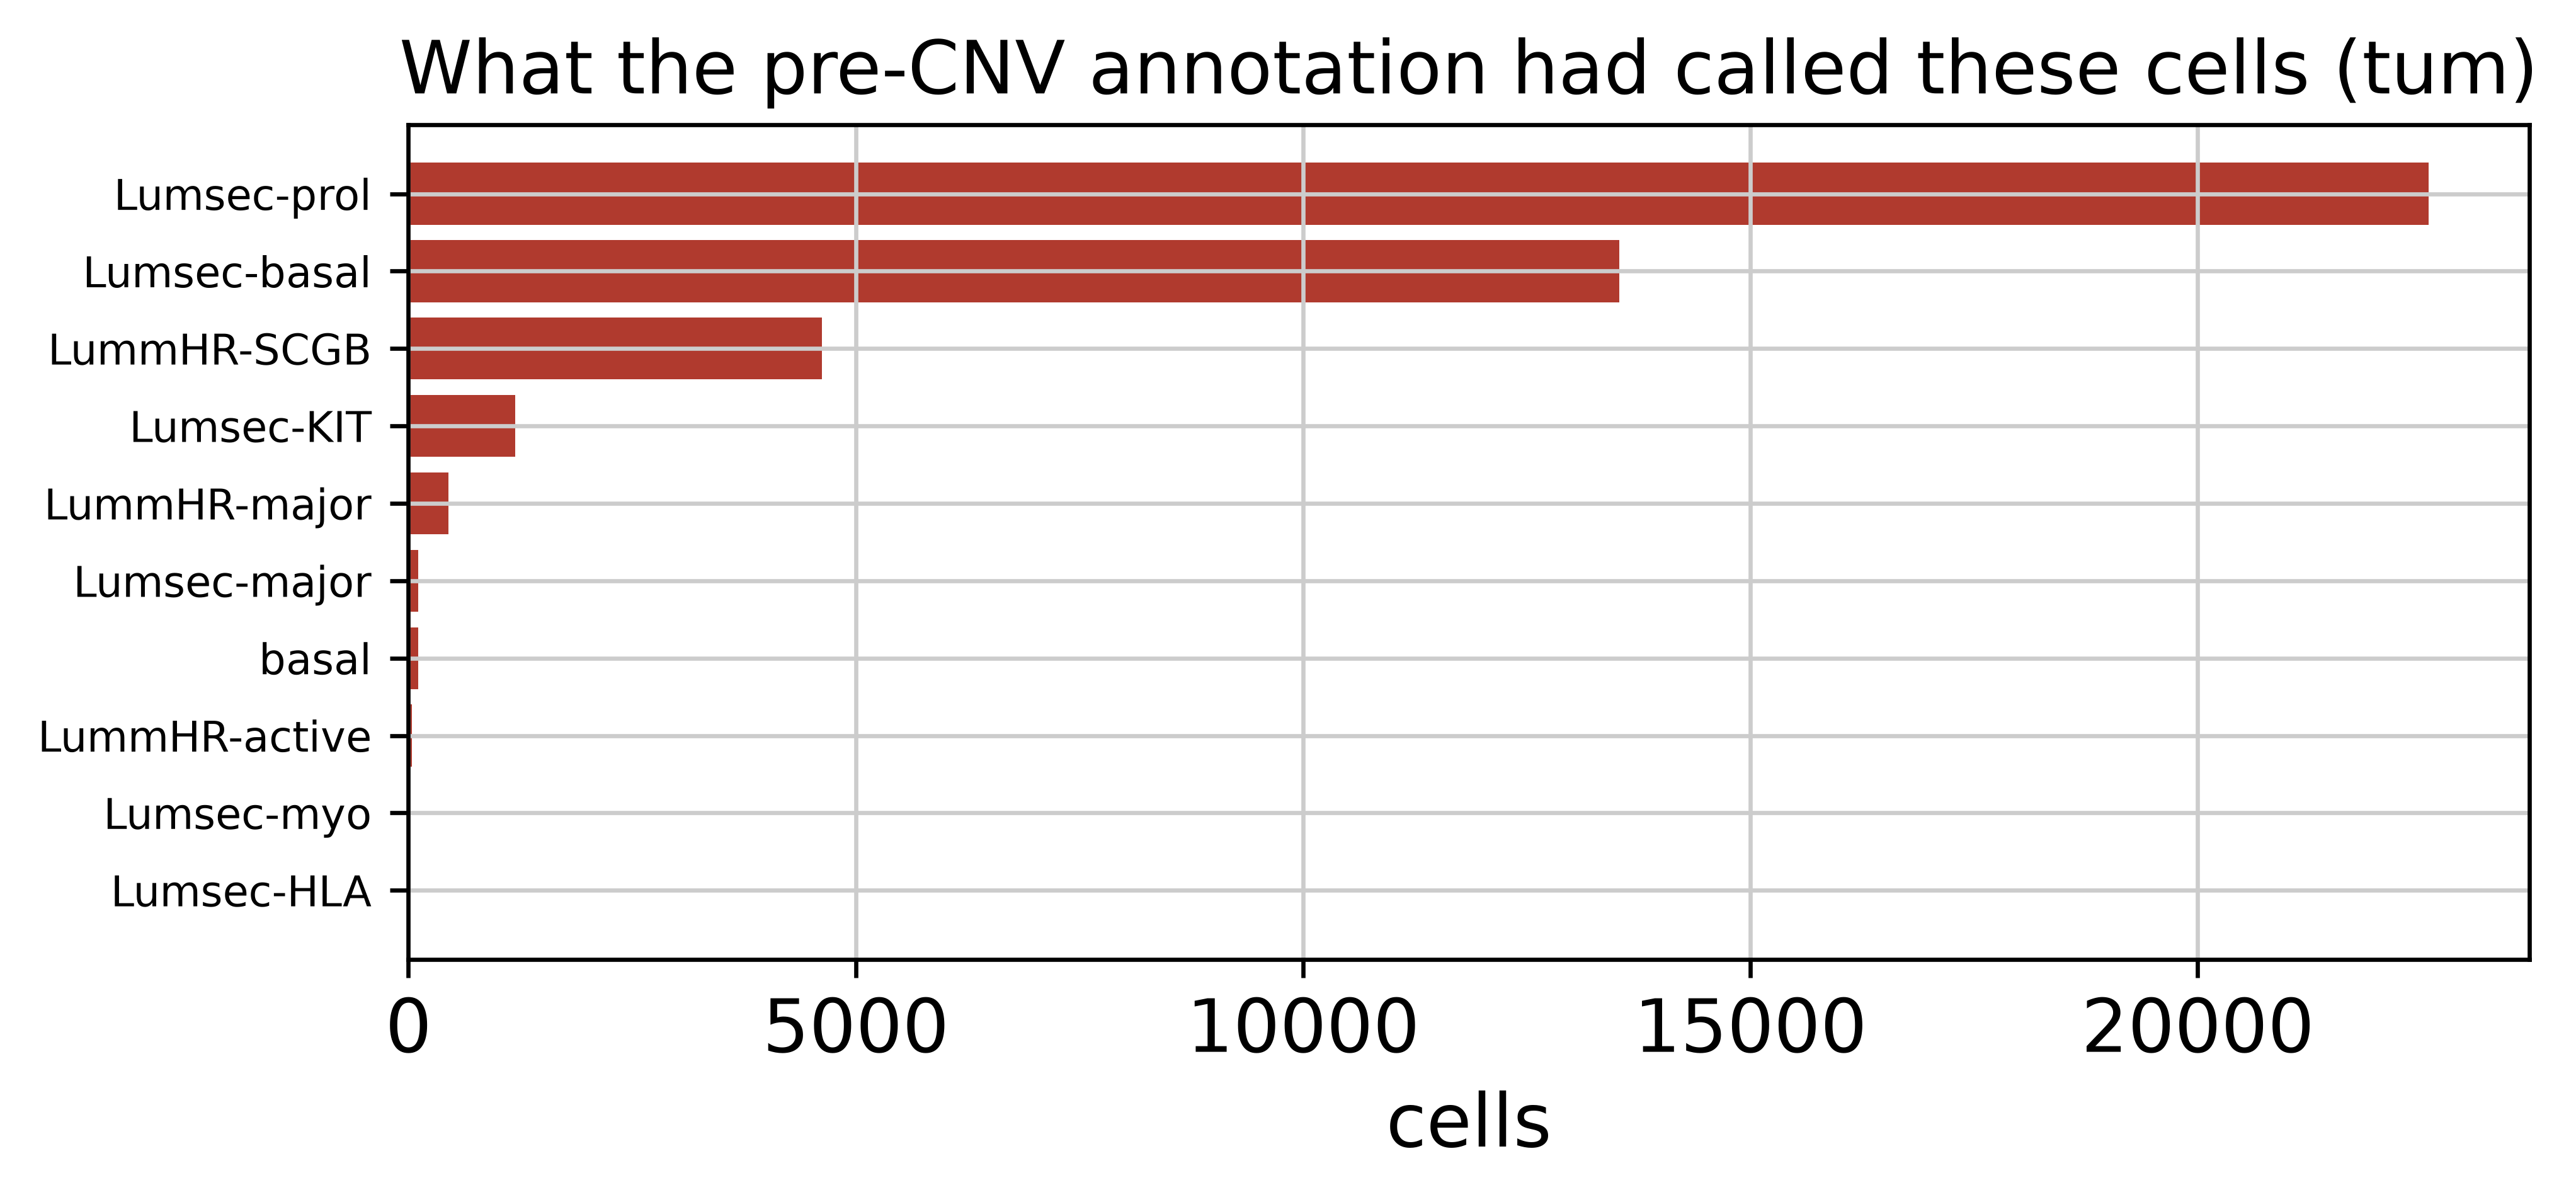

cnv_status,malignant
cell_type_01_4,
Lumsec-prol,22578
Lumsec-basal,13533
LummHR-SCGB,4621
Lumsec-KIT,1197
LummHR-major,446
Lumsec-major,111
basal,108
LummHR-active,40
Lumsec-myo,7


In [9]:
# What the tumour was being mistaken for. The single most informative panel of this notebook:
# the CellTypist model has no malignant class, so it had to put these cells somewhere, and this is
# where. Under CELL_SET=epi the same panel splits malignant from non-malignant within each label.
comp = (sub.obs.groupby([C.PRIOR_LABEL_KEY, C.STATUS_KEY], observed=True).size()
        .unstack(fill_value=0))
comp = comp.loc[comp.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(7, max(3, 0.34 * len(comp))))
left = np.zeros(len(comp))
palette = {'malignant': QC_COLOR, 'non_malignant': '#9AA5B1'}
for col in comp.columns:
    ax.barh(range(len(comp)), comp[col], left=left, color=palette.get(col, '#cccccc'), label=col)
    left += comp[col].to_numpy()
ax.set_yticks(range(len(comp)))
ax.set_yticklabels(comp.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('cells')
ax.set_title(f'What the pre-CNV annotation had called these cells ({C.compartment()})')
if comp.shape[1] > 1:
    ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f'composition_by_prior_label_{C.compartment()}.png'), dpi=300,
            bbox_inches='tight')
plt.show()
comp

## Restore the raw counts and drop the phase-01 global slots

`.X` in `shiao.h5ad` is the scran log-normalized matrix of the full object: its size factors were
deconvolved from pools of 619,693 cells and do not describe this subset. `.layers['counts']` is the
only matrix that survives a subset unchanged, so it becomes `.X` again and `scran_norm_tum.py`
re-normalizes from there.

The same argument applies to everything else phase 01 derived: the PCA was computed on HVGs
selected across a population 94% of which is not in this subset, the neighbour graph and the UMAP
on that PCA, the leiden columns on that graph. Keeping any of it would be worse than useless -
`use_rep='X_pca'` downstream would silently point at the old embedding.

The colour palettes in `.uns` go too, and that one is easy to miss: `cell_type_colors` is keyed on
the 01_4 vocabulary, which is not the vocabulary of the column any more, so every scanpy plotting
call downstream would silently mis-assign colours.

In [10]:
# Raw counts back in .X (kept in .layers['counts'] as well, untouched)
counts = sub.layers['counts']
sub.X = counts.copy()
if sp.issparse(sub.X) and not sp.isspmatrix_csr(sub.X):
    sub.X = sub.X.tocsr()

x_values = sub.X.data if sp.issparse(sub.X) else np.asarray(sub.X).ravel()
print('dtype:', sub.X.dtype, '| integer values:', bool(np.allclose(x_values, np.round(x_values))))
print('min:', x_values.min(), '| max:', x_values.max())

dtype: float32 | integer values: True
min: 1.0 | max: 11105.0


In [11]:
# Drop the derived matrices and graphs
print('obsm:', list(sub.obsm), '| varm:', list(sub.varm), '| obsp:', list(sub.obsp))
del sub.obsm, sub.obsp, sub.varm

dropped_uns = []
for key in list(sub.uns):
    if key.startswith(('pca', 'neighbors', 'umap', 'optscib_')) or key == 'log1p':
        del sub.uns[key]; dropped_uns.append(key)
# Stale palettes: `cell_type` has a different vocabulary now.
for key in ('cell_type_colors', 'dataset_origin_colors'):
    if sub.uns.pop(key, None) is not None:
        dropped_uns.append(key)
print('uns dropped:', dropped_uns)
print('uns left   :', list(sub.uns))

obsm: ['X_pca', 'X_umap'] | varm: ['PCs'] | obsp: ['connectivities', 'distances']
uns dropped: ['log1p', 'neighbors', 'optscib_unintegrated_leiden_0.1', 'optscib_unintegrated_leiden_0.2', 'optscib_unintegrated_leiden_0.3', 'optscib_unintegrated_leiden_0.4', 'optscib_unintegrated_leiden_0.5', 'optscib_unintegrated_leiden_0.6', 'optscib_unintegrated_leiden_0.7', 'optscib_unintegrated_leiden_0.8', 'optscib_unintegrated_leiden_0.9', 'optscib_unintegrated_leiden_1.0', 'pca', 'umap', 'cell_type_colors', 'dataset_origin_colors']
uns left   : []


In [12]:
# Drop the derived .obs columns: scran size factors, the leiden sweep of 01_5, and the cell cycle
# scores (re-scored in the next step against expression bins built on THIS population).
DROP_OBS = ['size_factors', 'S_score', 'G2M_score', 'phase']
DROP_OBS += [c for c in sub.obs.columns if c.startswith('optscib_unintegrated_leiden')]
present = [c for c in DROP_OBS if c in sub.obs]
sub.obs.drop(columns=present, inplace=True)
print('obs dropped:', present)

# .var: the per-gene stats and the HVG flag were computed over the full object.
DROP_VAR = ['highly_variable', 'n_cells', 'n_cells_by_counts', 'mean_counts',
            'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts']
present_var = [c for c in DROP_VAR if c in sub.var]
sub.var.drop(columns=present_var, inplace=True)
print('var dropped:', present_var)
print()
print('obs left:', list(sub.obs.columns))

obs dropped: ['size_factors', 'S_score', 'G2M_score', 'phase', 'optscib_unintegrated_leiden_0.1', 'optscib_unintegrated_leiden_0.2', 'optscib_unintegrated_leiden_0.3', 'optscib_unintegrated_leiden_0.4', 'optscib_unintegrated_leiden_0.5', 'optscib_unintegrated_leiden_0.6', 'optscib_unintegrated_leiden_0.7', 'optscib_unintegrated_leiden_0.8', 'optscib_unintegrated_leiden_0.9', 'optscib_unintegrated_leiden_1.0', 'optscib_unintegrated_leiden']
var dropped: ['highly_variable', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts']

obs left: ['sample', 'batch', 'cohort', 'treatment', 'fraction', 'dataset_origin', 'response', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'is_doublet_shiao', 'high_umi_doublet', 'cel

### `fraction`, recomputed

`fraction` is a function of `cell_type` - 01_4 built it as a lookup against the immune lineage list
- and `cell_type` has just been replaced by the post-CNV label. The inherited column is therefore
stale, and recomputing it is the whole of `fraction_reassignment.py`: no model, no state, a lookup.

Under `CELL_SET=tum` this changes nothing (every malignant cell was epithelial, hence `non_imm`
already) and the assertion below is the proof. Under `epi` it does change something, because the
re-annotation moved 2,821 cells from an immune label to an epithelial one.

In [13]:
old_fraction = sub.obs['fraction'].astype(str).copy()
sub.obs['fraction'] = C.reassign_fraction(sub.obs[C.LABEL_KEY].astype(str))
moved = (old_fraction != sub.obs['fraction'].astype(str))
print(f'fraction recomputed: {moved.sum():,} of {sub.n_obs:,} cells changed')
if moved.any():
    print(pd.crosstab(old_fraction[moved], sub.obs['fraction'].astype(str)[moved]).to_string())
print()
print(sub.obs['fraction'].value_counts().to_string())

fraction recomputed: 0 of 42,643 cells changed

fraction
non_imm    42643
imm            0


### Categories left empty by the subset

`cell_type` was a categorical with 48 observed labels in the full object; after the subset only a
few carry cells. Empty categories are not cosmetic: they end up in the NMI computation of the
leiden sweep, in every `groupby`, and in the legend of every figure.

In [14]:
for col in sub.obs.columns:
    if isinstance(sub.obs[col].dtype, pd.CategoricalDtype):
        before = len(sub.obs[col].cat.categories)
        sub.obs[col] = sub.obs[col].cat.remove_unused_categories()
        after = len(sub.obs[col].cat.categories)
        if before != after:
            print(f'{col}: {before} -> {after} categories')

print()
print('Observed post-CNV labels :', sub.obs[C.LABEL_KEY].nunique())
print('Observed pre-CNV labels  :', sub.obs[C.PRIOR_LABEL_KEY].nunique())
print('Observed batches         :', sub.obs[C.BATCH_KEY].nunique())
print('compartment:', sub.obs[C.COMPARTMENT_KEY].cat.categories.tolist(),
      '| fraction:', sub.obs['fraction'].cat.categories.tolist())

fraction: 2 -> 1 categories

Observed post-CNV labels : 1
Observed pre-CNV labels  : 10
Observed batches         : 24
compartment: ['tum'] | fraction: ['non_imm']


## Quality control metrics, recomputed

The QC columns inherited from 01_2 describe the full gene set of the full object. `total_counts`
and `n_genes_by_counts` are per-cell sums, so removing *cells* leaves them unchanged - but they
will change as soon as genes are dropped below, and the mitochondrial and ribosomal flags have to
be rebuilt on the current `.var` anyway.

In [15]:
# np.asarray(..., bool): var_names is a pandas StringDtype index here, so .str.startswith returns
# a nullable BooleanArray, which calculate_qc_metrics cannot index with.
sub.var['mt'] = np.asarray(sub.var_names.str.startswith('MT-'), dtype=bool)
sub.var['ribo'] = np.asarray(sub.var_names.str.startswith(('RPS', 'RPL')), dtype=bool)
print('mitochondrial genes:', int(sub.var['mt'].sum()), '| ribosomal:', int(sub.var['ribo'].sum()))

sc.pp.calculate_qc_metrics(sub, qc_vars=['mt', 'ribo'], percent_top=None, log1p=True, inplace=True)
sub.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo']].describe().round(2)

mitochondrial genes: 13 | ribosomal: 102


,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_ribo
count,42643.00,42643.00,42643.00,42643.00
mean,1795.21,6276.93,3.73,17.70
std,1357.62,7615.04,2.86,8.43
min,142.00,195.00,0.00,0.42
25%,668.00,1168.00,1.13,12.21
50%,1389.00,3284.00,3.33,16.20
75%,2588.00,8481.00,5.90,21.37
max,7886.00,65338.00,10.00,71.20


### QC figures (before the cell filter)

One panel per round, in the layout 04 uses: the top row is the clean violin, the bottom row the same
violin with every cell drawn on top of it. Same metrics, same figsize, same file naming as chapter
04, so the two can be read side by side - only the colour and the cells differ.

wrote violin_tum_qc_before_filter_unintegrated_comparison.png


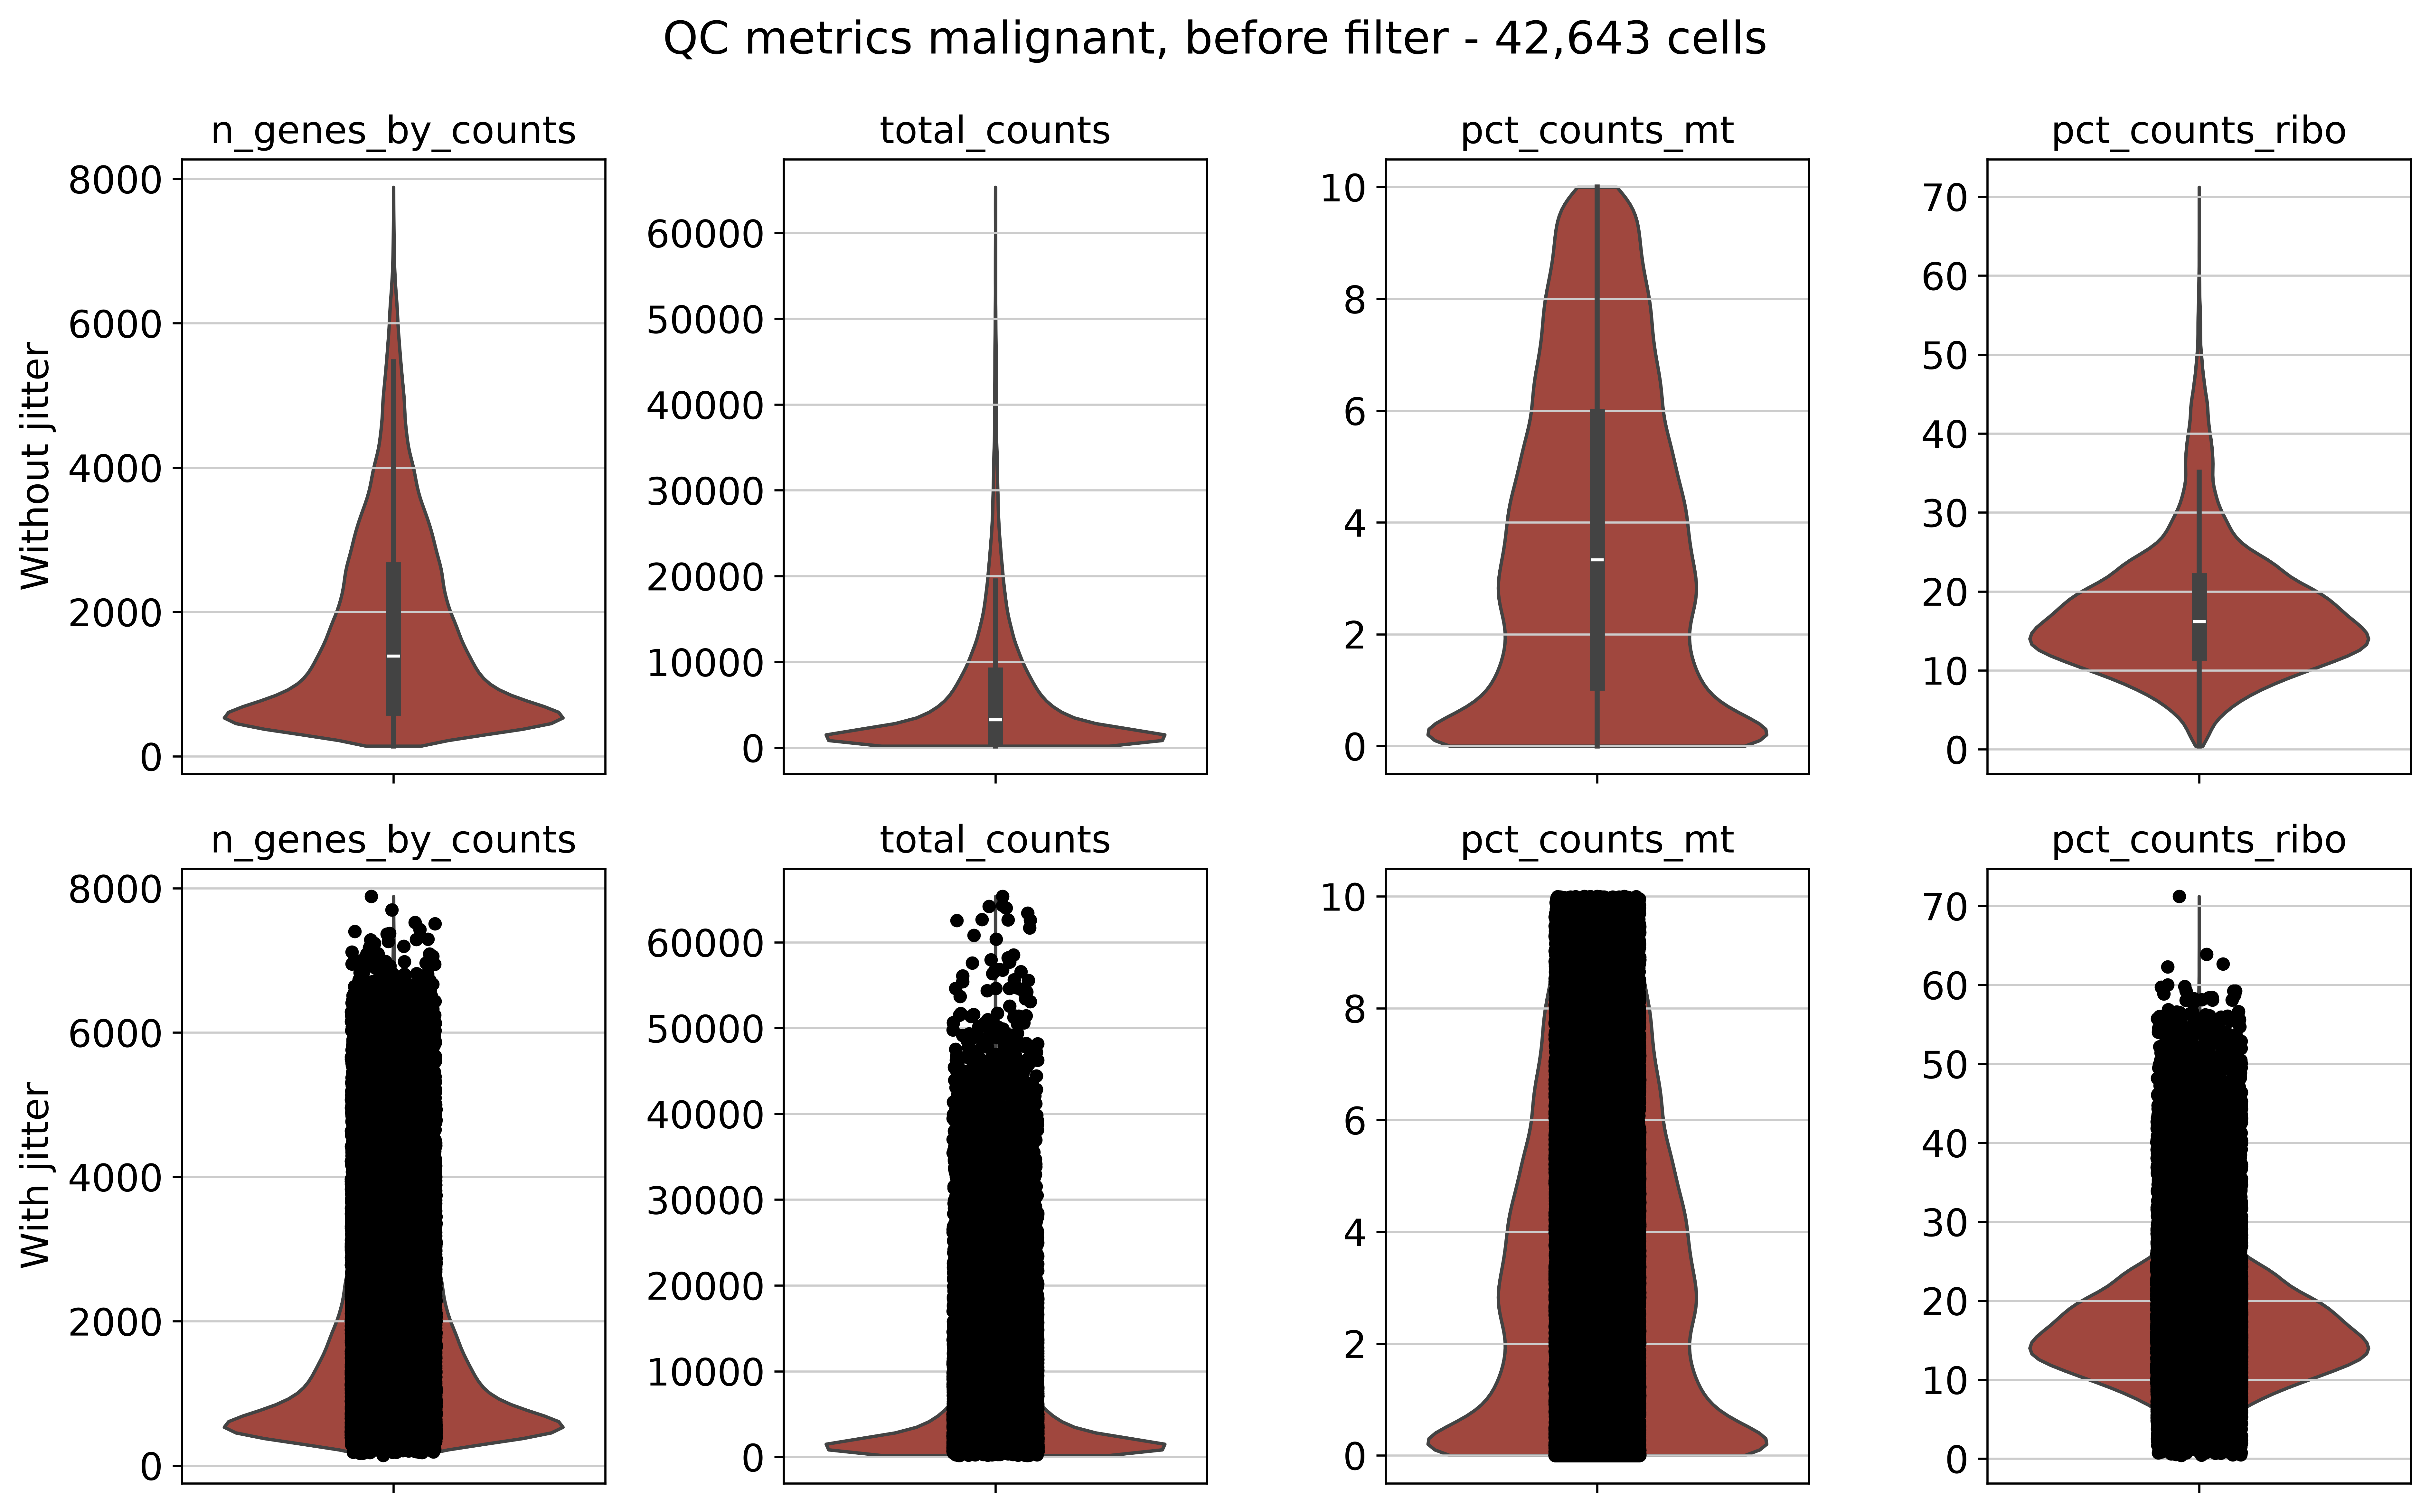

In [16]:
QC_METRICS = ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo']

def violin_qc(obs, stage, suffix=None, metrics=QC_METRICS):
    """The 2 x 4 comparison panel of 04: top row without jitter, bottom row with it.

    Same layout, same figsize, same stripplot settings and same file naming as
    04_1/visualization_epi.ipynb, so the two chapters can be put side by side and the only
    thing that differs is the colour and the cells.
    """
    suffix = suffix or C.compartment()
    fig, axes = plt.subplots(2, len(metrics), figsize=(3.2 * len(metrics), 8))

    for col, metric in enumerate(metrics):
        # Normal violin
        sns.violinplot(data=obs, y=metric, ax=axes[0, col], color=QC_COLOR, cut=0)

        # Violin + default jitter
        sns.violinplot(data=obs, y=metric, ax=axes[1, col], color=QC_COLOR, cut=0)
        sns.stripplot(data=obs, y=metric, ax=axes[1, col], jitter=True, color='black')

        # Formatting
        axes[0, col].set_title(metric)
        axes[1, col].set_title(metric)
        for row in range(2):
            axes[row, col].set_xlabel('')
            axes[row, col].set_ylabel('')

    # Row labels
    axes[0, 0].set_ylabel('Without jitter')
    axes[1, 0].set_ylabel('With jitter')

    fig.suptitle(f"QC metrics {SET_TITLES[C.cell_set()]}, {stage.replace('_', ' ')} "
                 f"- {len(obs):,} cells")
    fig.tight_layout()

    name = f'violin_{suffix}_qc_{stage}_unintegrated_comparison.png'
    fig.savefig(os.path.join(FIG_DIR, name), dpi=300, bbox_inches='tight')
    print('wrote', name)
    plt.show()


violin_qc(sub.obs, 'before_filter')

/tmp/ipykernel_67545/2099286763.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.scatter(


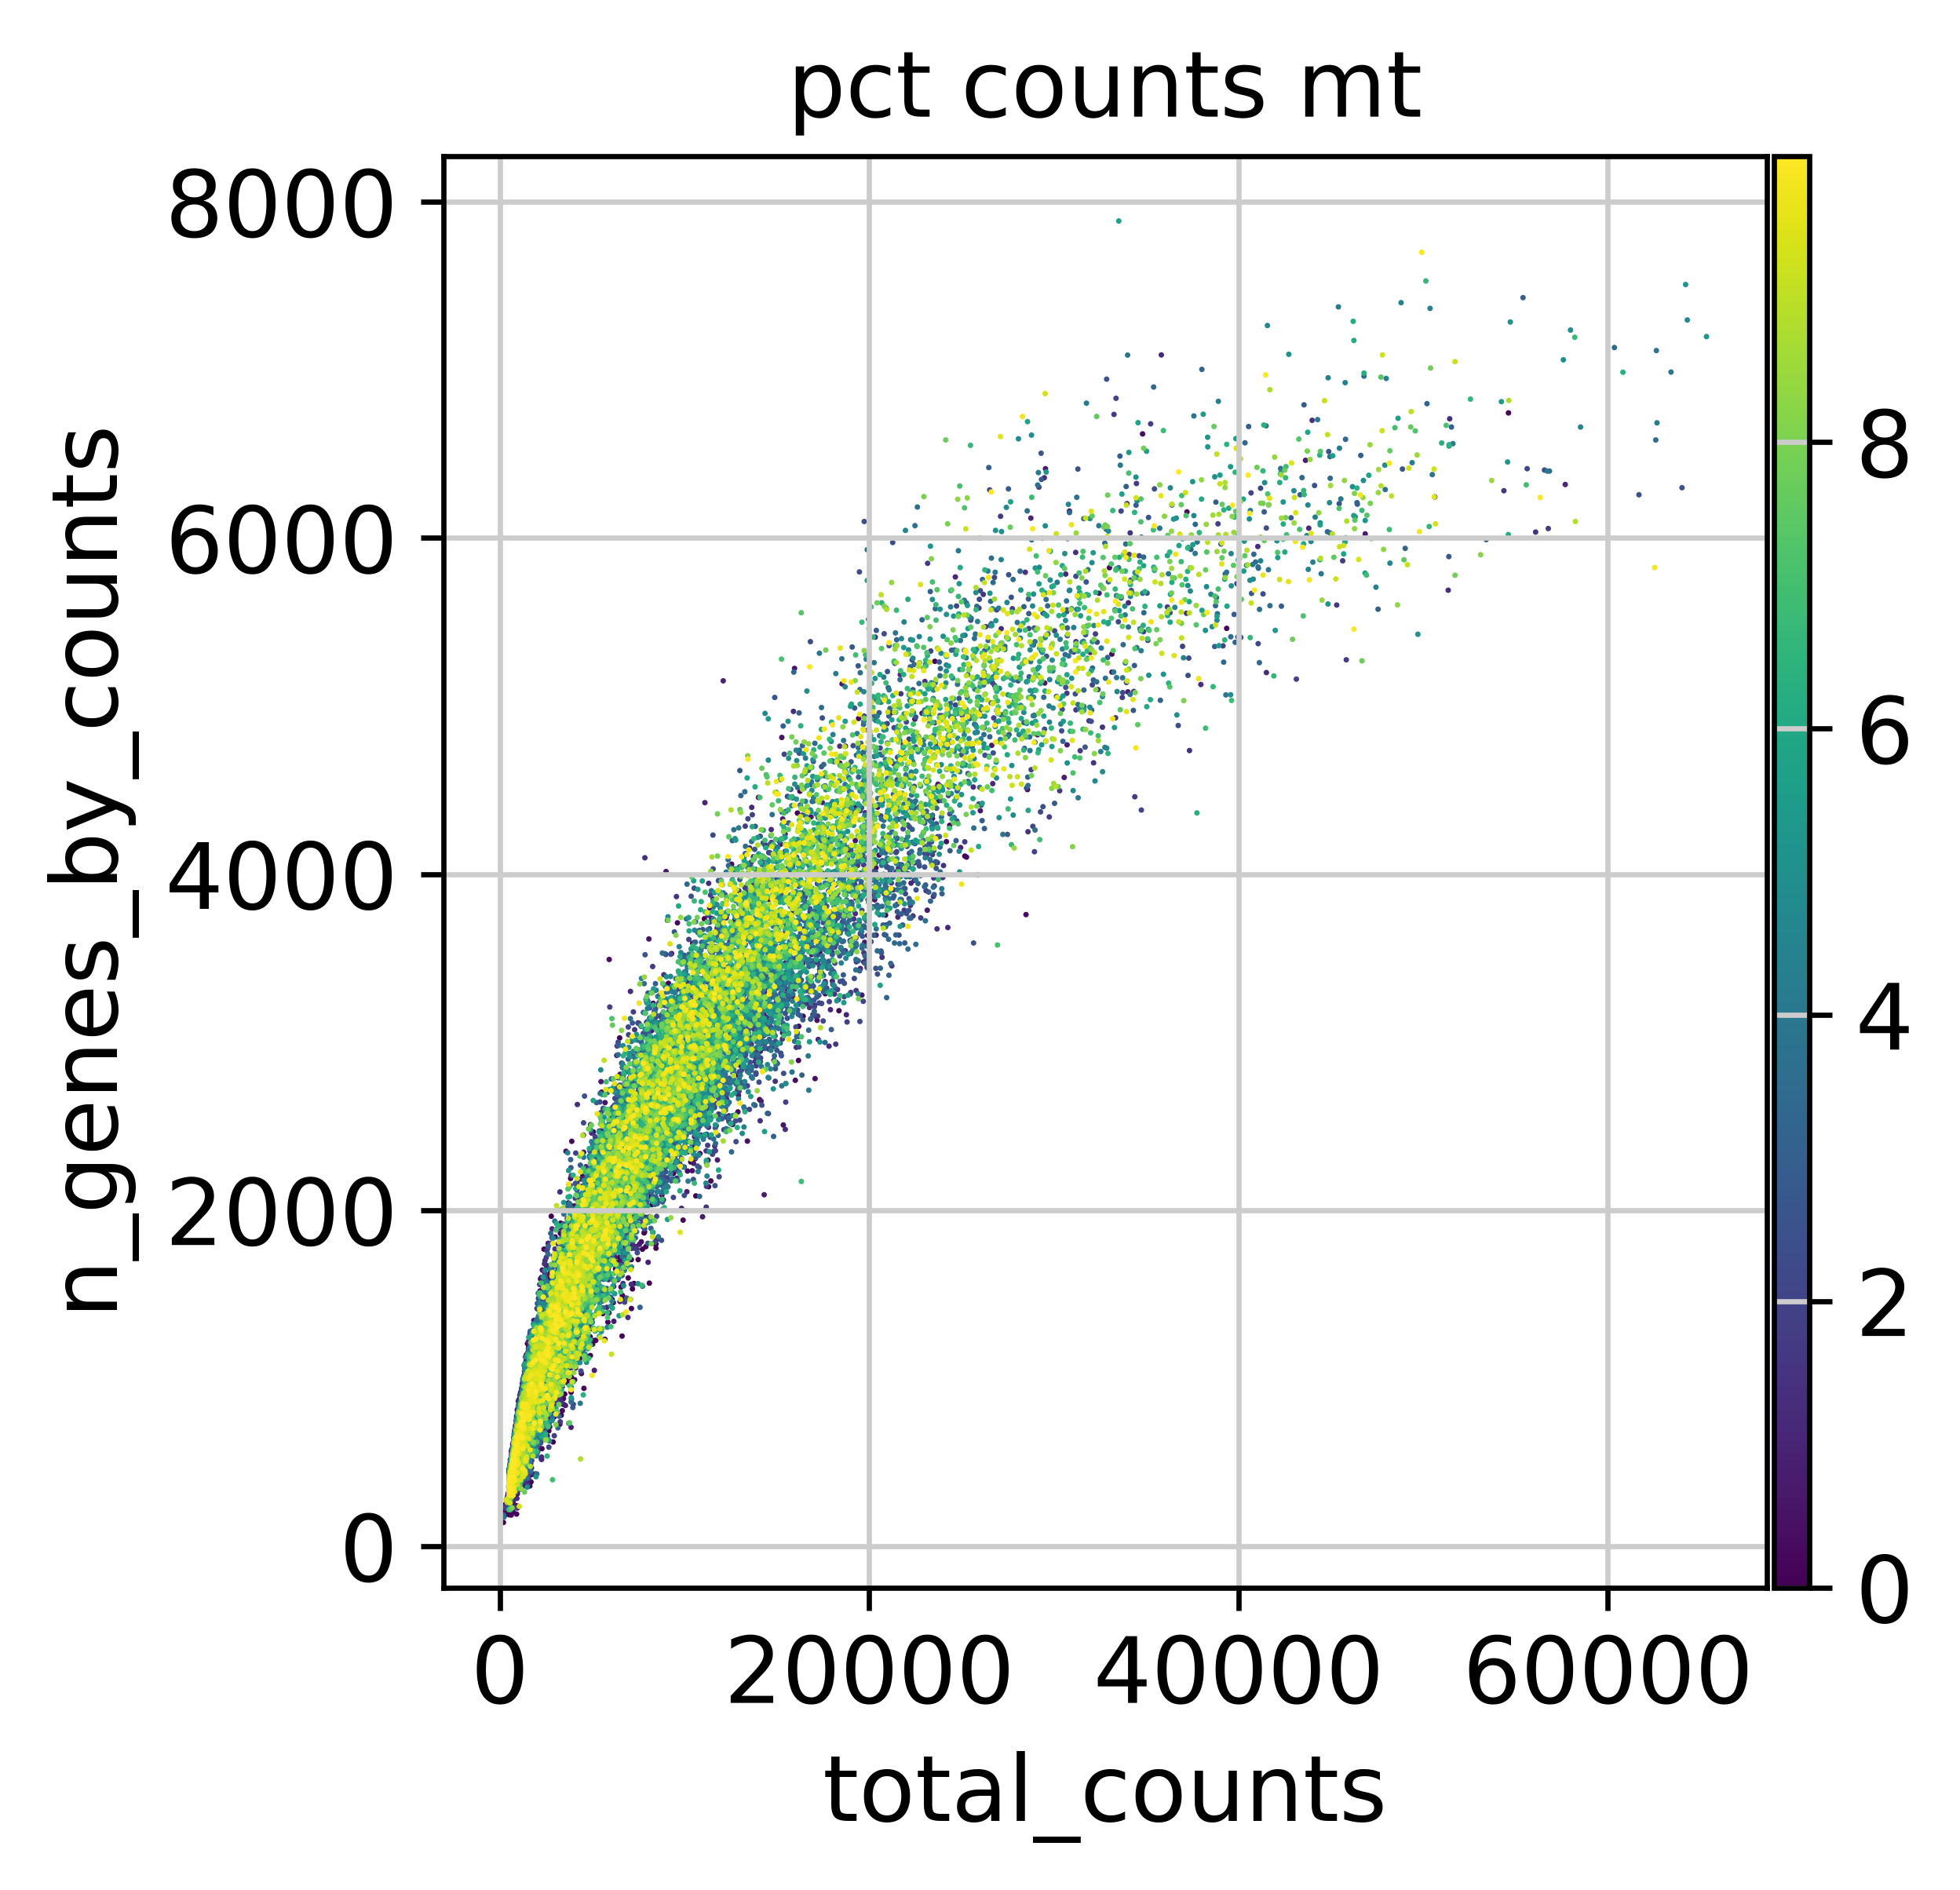

In [17]:
# The usual complexity scatter: counts vs genes, coloured by mitochondrial content.
sc.pl.scatter(
    sub,
    x='total_counts',
    y='n_genes_by_counts',
    color='pct_counts_mt',
    save=f'_{C.compartment()}_counts_vs_genes.png',
)

Text(0.5, 0, 'total_counts')

Text(0, 0.5, 'cnv_score')

Text(0.5, 1.0, 'cnv_score vs library size   (r = +0.138 on log10 counts)')

Text(0.5, 0, 'total_counts')

Text(0, 0.5, 'cnv_corr')

Text(0.5, 1.0, 'cnv_corr vs library size   (r = +0.535 on log10 counts)')

Text(0.5, 1.02, 'Within this subset only - see the comment for the whole-cohort figure')

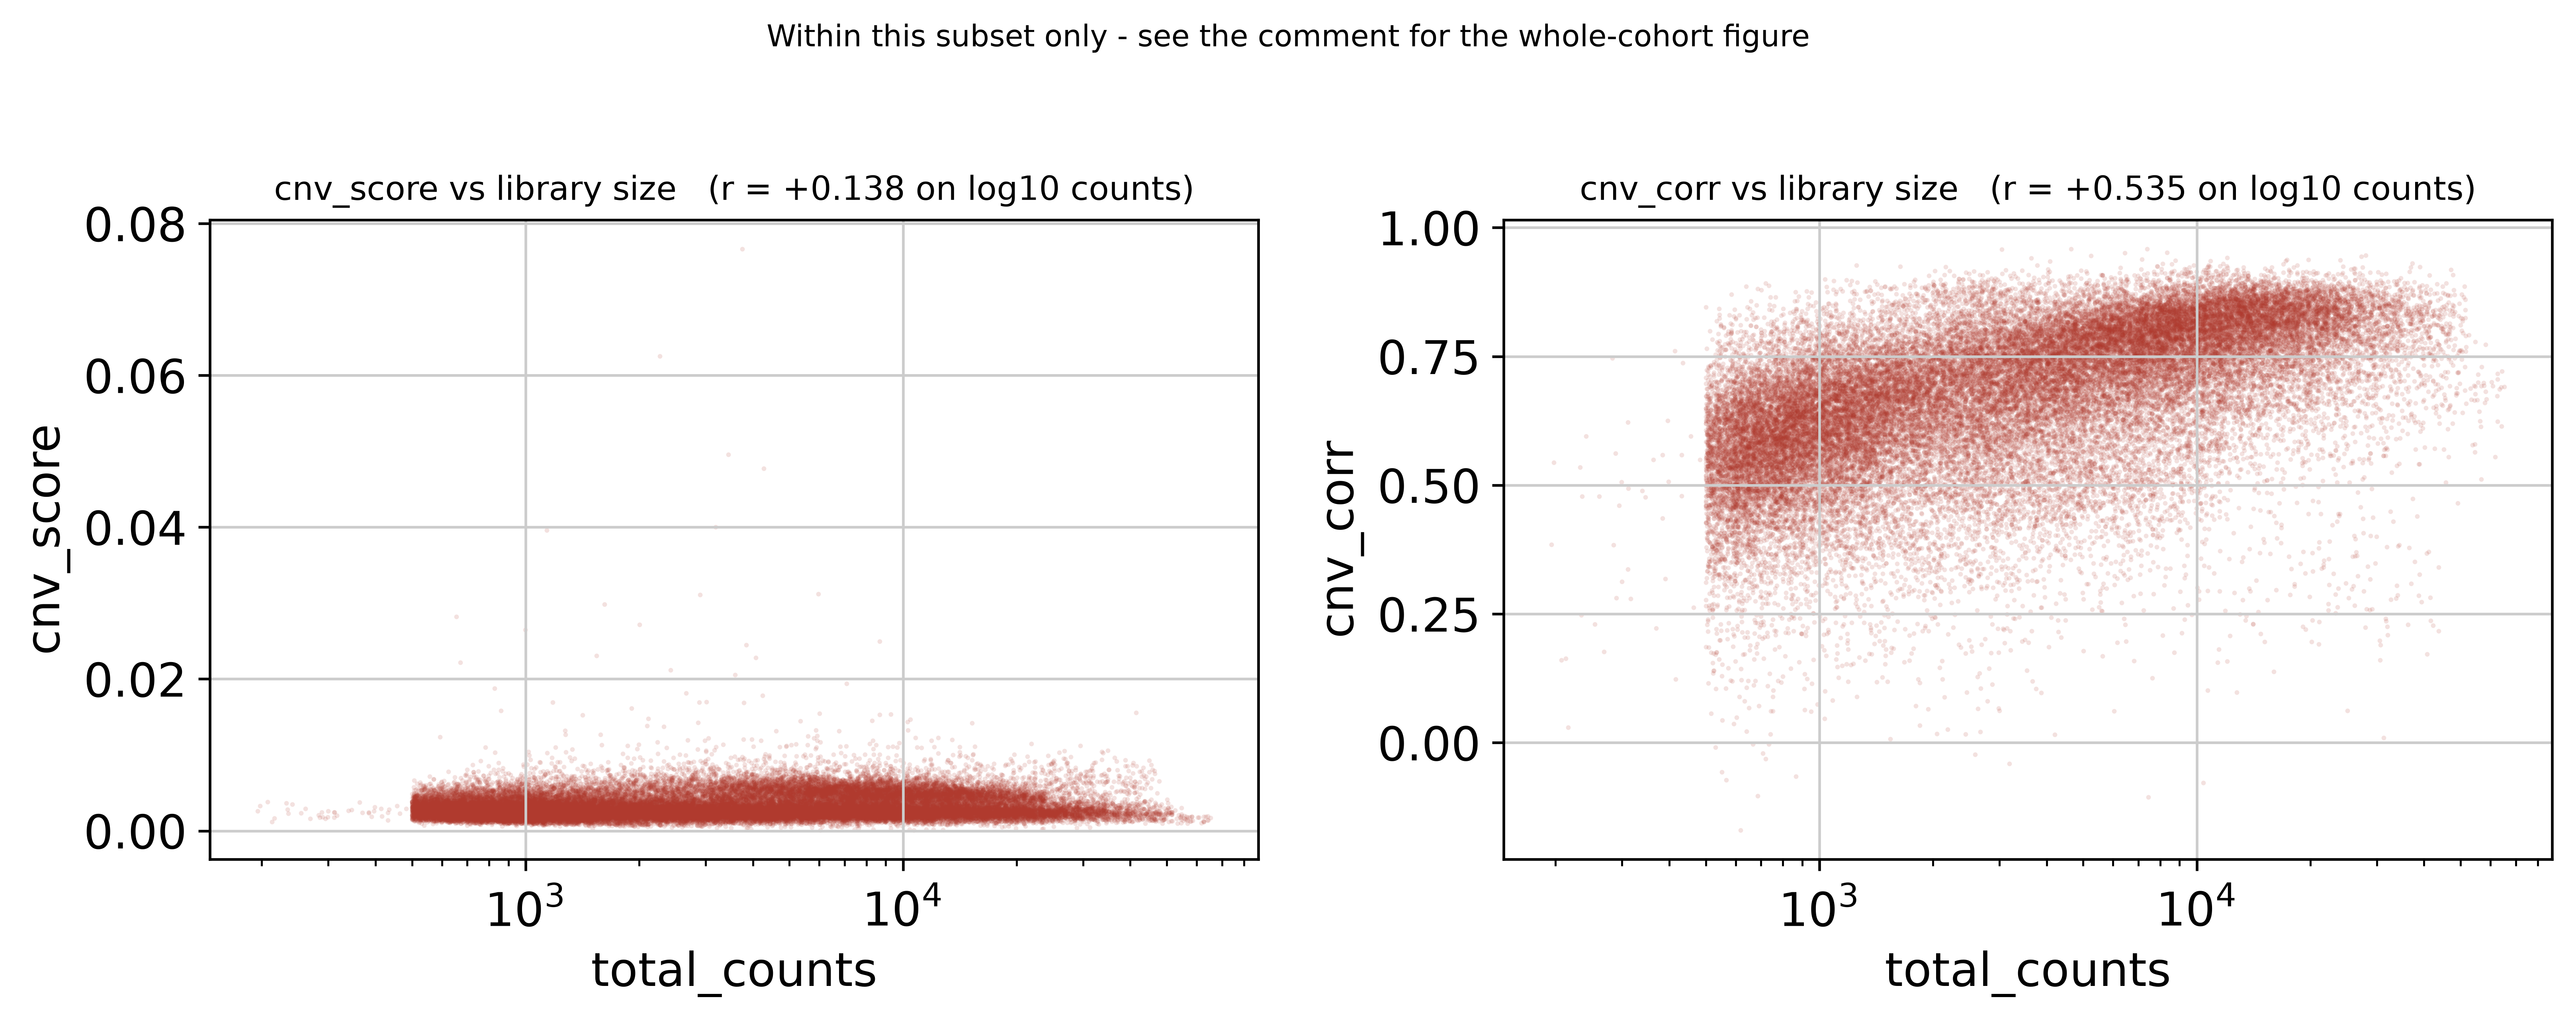

within this subset  : r(cnv_score) = +0.138 | r(cnv_corr) = +0.535
(across ALL cells 05_1 tested the same correlations are +/-0.08 - the call itself is not depth-driven; it is the within-tumour gradient that is)


In [18]:
# The two CNV axes against sequencing depth. No counterpart in 04_1, because 04 had no such
# axes. Two different questions, and they have different answers here:
#
#   1. is the SUBSET a depth artefact? Measured across every cell 05_1 tested, where the call
#      was actually made. r is +/-0.08 on both axes: no. The malignant/non-malignant split is
#      not "the deeply sequenced cells".
#   2. is cnv_corr usable as a continuous "how malignant" covariate INSIDE the tumour? No.
#      Within the malignant cells r(cnv_corr, log10 counts) = +0.57. That is regression
#      dilution doing what it always does - a shallow cell's residual profile is noisier, so
#      its correlation with any reference profile is attenuated - and it means cnv_corr
#      carries depth as well as karyotype once the diploid cells are gone.
#
# The consequence, and it belongs here rather than in a later step: cnv_score and cnv_corr
# travel with the object as provenance for the call, NOT as covariates to correlate latent
# dimensions against in 05_6. Doing that would rediscover library size.
if 'cnv_score' in sub.obs:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    for ax, col in zip(axes, ['cnv_score', 'cnv_corr']):
        ax.scatter(sub.obs['total_counts'], sub.obs[col], s=2, alpha=0.15, linewidths=0,
                   color=QC_COLOR, rasterized=True)
        ax.set_xscale('log')
        ax.set_xlabel('total_counts'); ax.set_ylabel(col)
        r = np.corrcoef(np.log10(sub.obs['total_counts']), sub.obs[col])[0, 1]
        ax.set_title(f'{col} vs library size   (r = {r:+.3f} on log10 counts)', fontsize=10)
    fig.suptitle('Within this subset only - see the comment for the whole-cohort figure', y=1.02,
                 fontsize=9)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f'cnv_axes_vs_depth_{C.compartment()}.png'), dpi=200,
                bbox_inches='tight')
    plt.show()

    print('within this subset  : ' + ' | '.join(
        f"r({c}) = {np.corrcoef(np.log10(sub.obs['total_counts']), sub.obs[c])[0, 1]:+.3f}"
        for c in ('cnv_score', 'cnv_corr')))
    print('(across ALL cells 05_1 tested the same correlations are +/-0.08 - the call itself is '
          'not depth-driven; it is the within-tumour gradient that is)')

## Cell filter

Same criteria as 01_2 (`pct_counts_mt < 10`, `n_genes_by_counts > 100`), re-applied rather than
assumed: the report below is the evidence that the subset carries no cell the full-object filter
would have rejected, and the place to tighten `MIN_GENES` / `MAX_PCT_MT` if the figures above call
for it.

In [19]:
n_before = sub.n_obs
fail_genes = (sub.obs['n_genes_by_counts'] <= C.MIN_GENES)
fail_mt = (sub.obs['pct_counts_mt'] >= C.MAX_PCT_MT)
print(f'n_genes_by_counts <= {C.MIN_GENES} : {int(fail_genes.sum()):,} cells')
print(f'pct_counts_mt     >= {C.MAX_PCT_MT} : {int(fail_mt.sum()):,} cells')
print(f'either                       : {int((fail_genes | fail_mt).sum()):,} cells')

sub = sub[~(fail_genes | fail_mt).to_numpy()].copy()
print(f'\nCells: {n_before:,} -> {sub.n_obs:,} ({100 * sub.n_obs / n_before:.1f}% retained)')

n_genes_by_counts <= 100 : 0 cells
pct_counts_mt     >= 10 : 0 cells
either                       : 0 cells



Cells: 42,643 -> 42,643 (100.0% retained)


## Gene filter

Placed after the cell filter, as in 01_2. Two reasons rather than one here: zero-count genes break
scran's `computeSumFactors`, and the 30,869 genes of the full object include everything that was
only expressed in the cells that just left - which, on this subset, is most of the dataset.

In [20]:
n_genes_before = sub.n_vars
detected = np.asarray((sub.X > 0).sum(axis=0)).ravel()
print(f'Total number of genes: {n_genes_before:,}')
print(f'  detected in 0 cells        : {int((detected == 0).sum()):,}')
print(f'  detected in < {C.MIN_CELLS} cells  : {int((detected < C.MIN_CELLS).sum()):,}')

sc.pp.filter_genes(sub, min_cells=C.MIN_CELLS)
print(f'Genes after the filter: {sub.n_vars:,} '
      f'({100 * sub.n_vars / n_genes_before:.1f}% retained)')

# QC columns are per-cell sums over the genes that are actually left.
sc.pp.calculate_qc_metrics(sub, qc_vars=['mt', 'ribo'], percent_top=None, log1p=True, inplace=True)

Total number of genes: 30,869
  detected in 0 cells        : 2,905
  detected in < 3 cells  : 5,620


filtered out 5620 genes that are detected in less than 3 cells


Genes after the filter: 25,249 (81.8% retained)


### QC figures (after the cell and gene filters)

wrote violin_tum_qc_after_cell_and_gene_filter_unintegrated_comparison.png


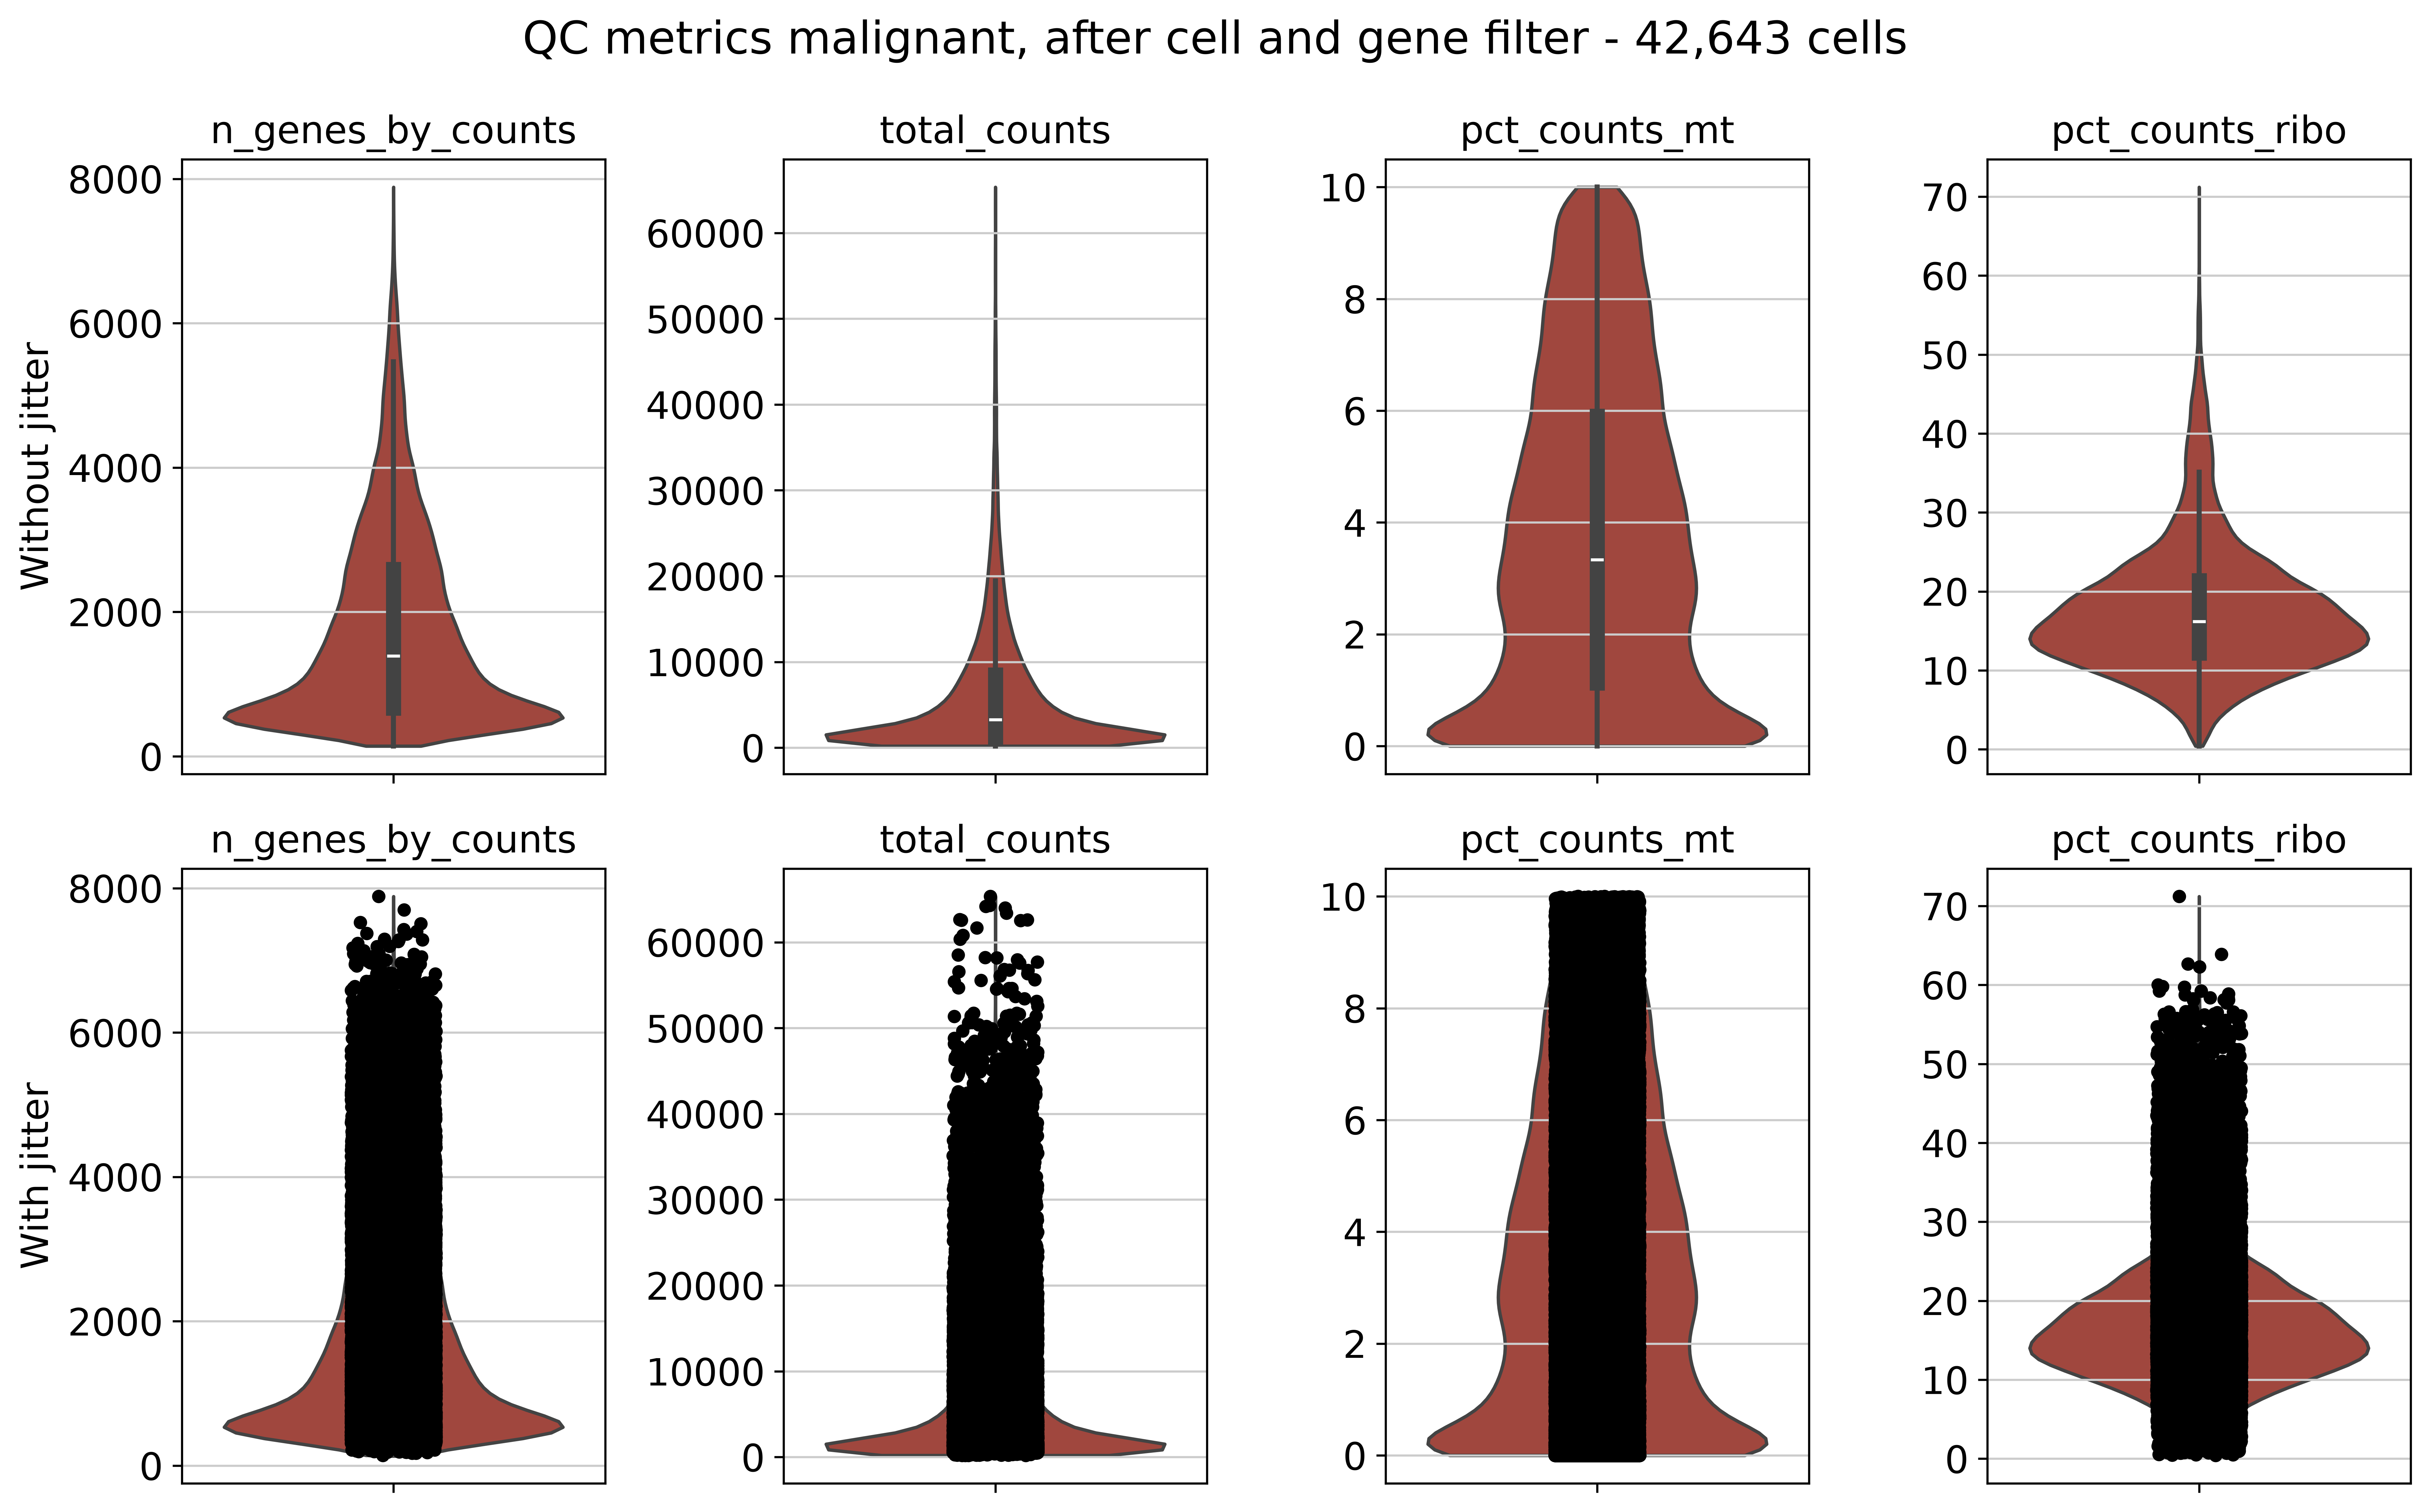

In [21]:
violin_qc(sub.obs, 'after_cell_and_gene_filter')

## Batch census

`cohort` is the batch key of everything downstream: scib's `hvg_batch` selects genes per patient
before merging, and DRVI is trained with `dispersion='gene-batch'`, which fits a dispersion per gene
*and* per batch. Both degrade on a patient contributing a few hundred cells.

**Size** (`MIN_CELLS_PER_COHORT = 200`): the same threshold as 04_1, and on this subset it is nearly
free. The per-cohort malignant counts are bimodal - a cohort has thousands of aneuploid cells or a
handful, with almost nothing between - so the table below barely moves across the plausible range.

**Completeness** (`DROP_INCOMPLETE_COHORTS`): **off**, unlike 04_1. It existed there because a
treatment phase was planned downstream; that phase is not planned any more, and on this subset the
filter is actively harmful - several cohorts clear it with two cells in a timepoint, while
Patient63 would lose 1,673 malignant cells for having none.

Both are judged *after* the QC filters above: a cohort can fall under the threshold here rather
than in the full object.

In [22]:
cells_per_cohort = sub.obs[C.BATCH_KEY].value_counts()
cells_per_cohort = cells_per_cohort[cells_per_cohort > 0]
print(f'{cells_per_cohort.size} cohorts | '
      f'min {cells_per_cohort.min():,} ({cells_per_cohort.idxmin()}) | '
      f'median {int(cells_per_cohort.median()):,} | '
      f'max {cells_per_cohort.max():,} ({cells_per_cohort.idxmax()})')

small = cells_per_cohort[cells_per_cohort < C.MIN_CELLS_PER_COHORT]
if len(small):
    print(f'\n{len(small)} cohort(s) below {C.MIN_CELLS_PER_COHORT} cells:')
    print(small.to_string())
else:
    print(f'\nNo cohort below {C.MIN_CELLS_PER_COHORT} cells.')

cells_per_cohort.sort_values()

24 cohorts | min 78 (Patient66) | median 832 | max 7,686 (Patient16)

5 cohort(s) below 200 cells:
cohort
Patient10    199
Patient05     94
Patient03     89
Patient30     87
Patient66     78


cohort
Patient66      78
Patient30      87
Patient03      89
Patient05      94
Patient10     199
Patient20     218
Patient42     278
Patient01     369
Patient64     455
Patient09     471
Patient48     475
Patient18     746
Patient19     919
Patient11    1116
Patient45    2106
Patient46    2218
Patient63    2317
Patient17    2387
Patient47    2690
Patient43    2745
Patient53    3900
Patient26    4849
Patient56    6151
Patient16    7686
Name: count, dtype: int64

In [23]:
# What the threshold actually costs, across the plausible range. This is the evidence behind
# keeping 200 rather than an argument for it.
rows = [{'threshold': t, 'cohorts': int((cells_per_cohort >= t).sum()),
         'cells': int(cells_per_cohort[cells_per_cohort >= t].sum())}
        for t in (50, 100, 150, 200, 300, 500)]
pd.DataFrame(rows).set_index('threshold')

,cohorts,cells
threshold,,
50,24,42643
100,20,42295
150,20,42295
200,19,42096
300,17,41600
500,13,39830


<BarContainer object of 24 artists>

Text(23.5, 229.99999999999997, 'MIN_CELLS_PER_COHORT = 200')

[Text(0, 0, 'Patient16'),
 Text(1, 0, 'Patient56'),
 Text(2, 0, 'Patient26'),
 Text(3, 0, 'Patient53'),
 Text(4, 0, 'Patient43'),
 Text(5, 0, 'Patient47'),
 Text(6, 0, 'Patient17'),
 Text(7, 0, 'Patient63'),
 Text(8, 0, 'Patient46'),
 Text(9, 0, 'Patient45'),
 Text(10, 0, 'Patient11'),
 Text(11, 0, 'Patient19'),
 Text(12, 0, 'Patient18'),
 Text(13, 0, 'Patient48'),
 Text(14, 0, 'Patient09'),
 Text(15, 0, 'Patient64'),
 Text(16, 0, 'Patient01'),
 Text(17, 0, 'Patient42'),
 Text(18, 0, 'Patient20'),
 Text(19, 0, 'Patient10'),
 Text(20, 0, 'Patient05'),
 Text(21, 0, 'Patient03'),
 Text(22, 0, 'Patient30'),
 Text(23, 0, 'Patient66')]

Text(0, 0.5, 'cells')

Text(0.5, 1.0, 'Cells per cohort (tum) - grey is dropped')

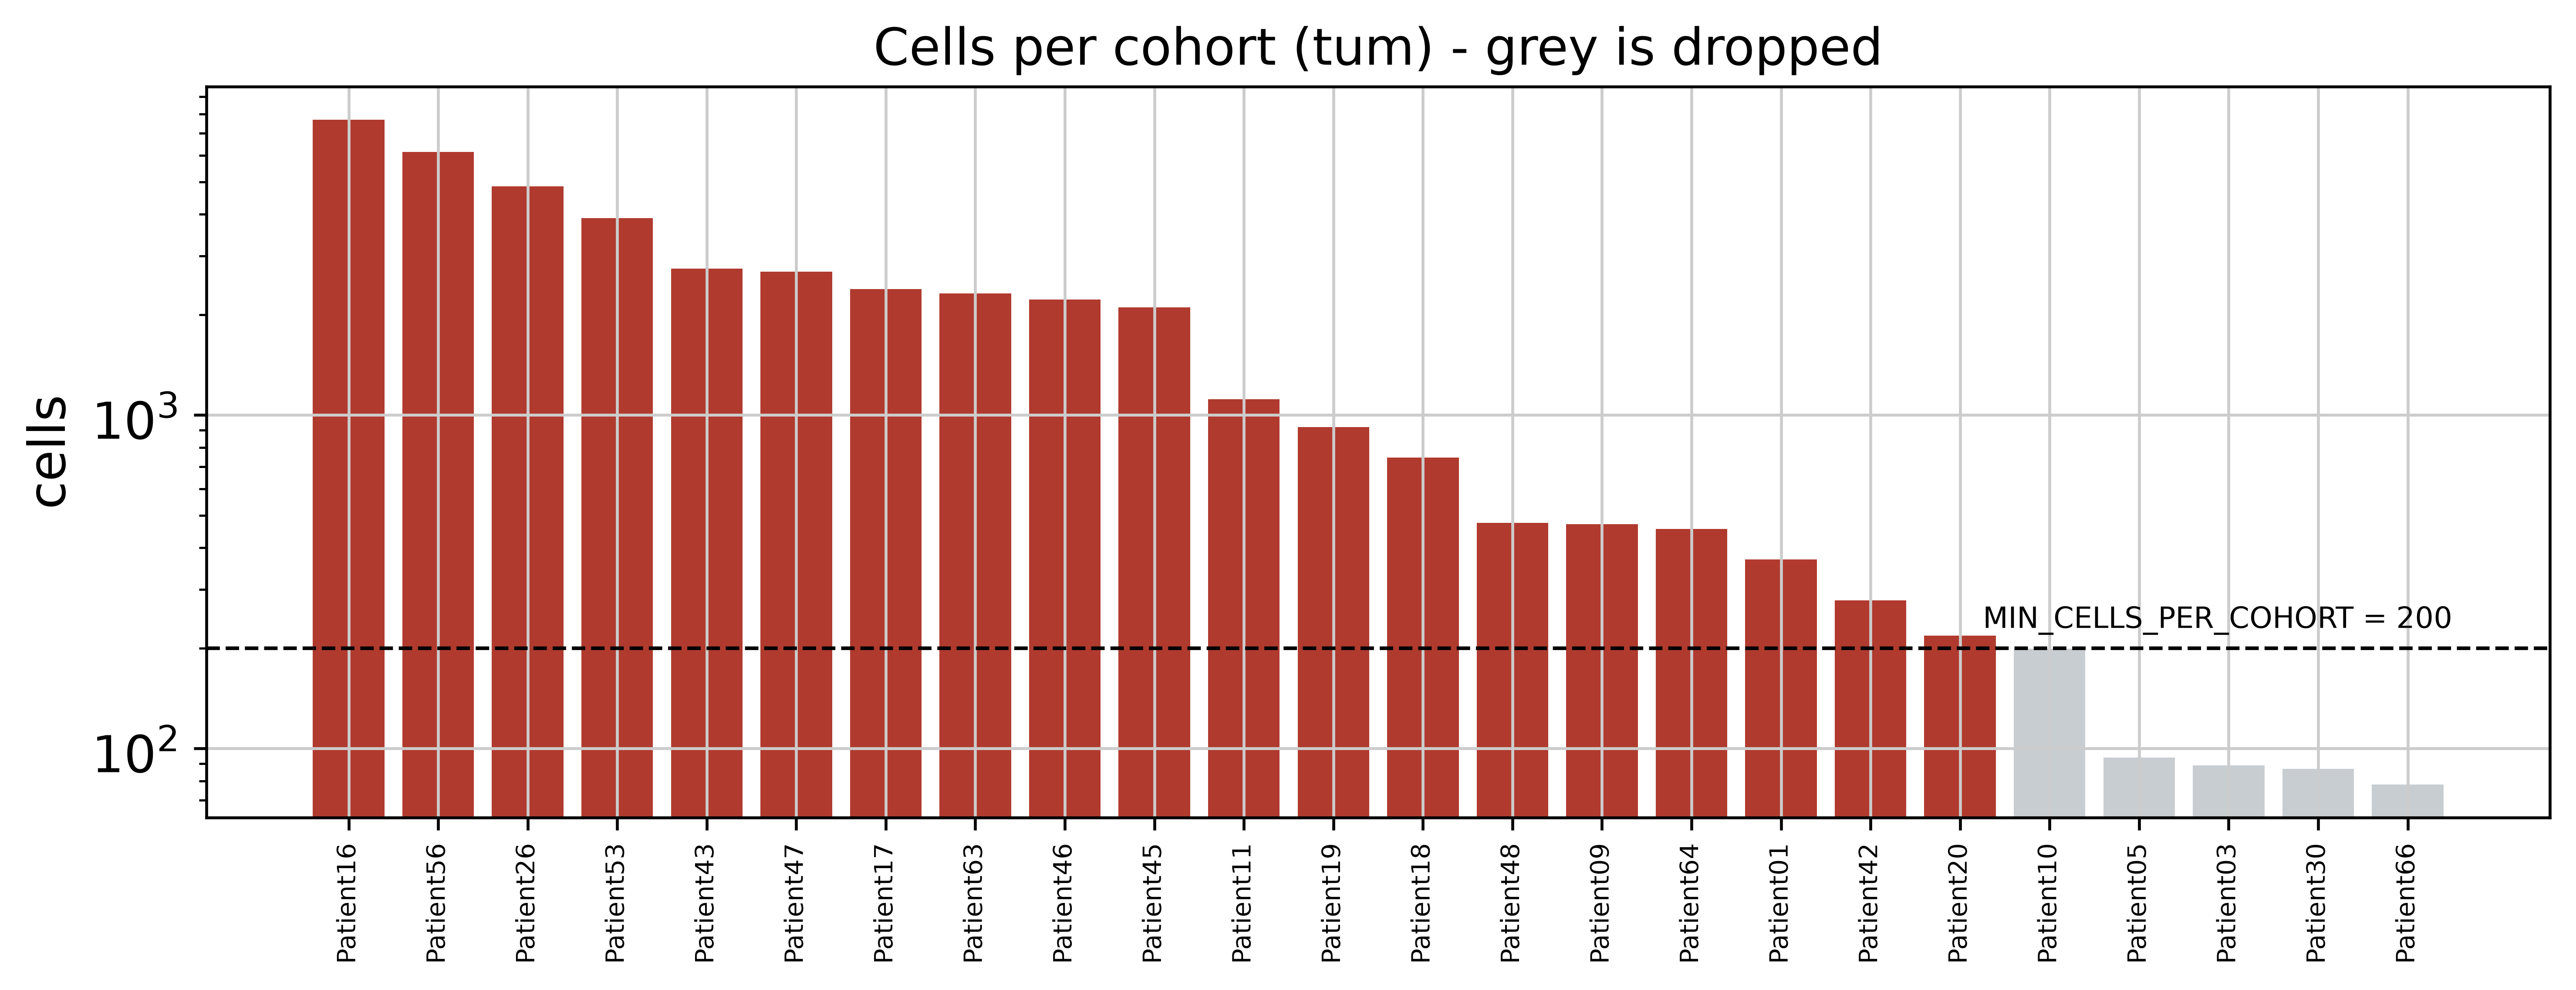

In [24]:
fig, ax = plt.subplots(figsize=(max(7, 0.42 * len(cells_per_cohort)), 4))
order = cells_per_cohort.sort_values(ascending=False)
kept = order >= C.MIN_CELLS_PER_COHORT
ax.bar(range(len(order)), order.to_numpy(),
       color=[QC_COLOR if k else '#C8CDD2' for k in kept])
ax.axhline(C.MIN_CELLS_PER_COHORT, color='black', ls='--', lw=1)
ax.text(len(order) - 0.5, C.MIN_CELLS_PER_COHORT * 1.15,
        f'MIN_CELLS_PER_COHORT = {C.MIN_CELLS_PER_COHORT}', ha='right', fontsize=8)
ax.set_yscale('log')
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order.index, rotation=90, fontsize=7)
ax.set_ylabel('cells')
ax.set_title(f'Cells per cohort ({C.compartment()}) - grey is dropped')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f'cells_per_cohort_{C.compartment()}.png'), dpi=300,
            bbox_inches='tight')
plt.show()

In [25]:
cohort_x_treatment = pd.crosstab(
    sub.obs[C.BATCH_KEY], sub.obs[C.TREATMENT_KEY]
).reindex(columns=list(C.REQUIRED_TREATMENTS), fill_value=0)

incomplete = cohort_x_treatment.index[(cohort_x_treatment == 0).any(axis=1)]
if len(incomplete):
    print(f"{len(incomplete)} cohort(s) missing at least one of "
          f"{'/'.join(C.REQUIRED_TREATMENTS)} "
          f"({'DROPPED' if C.DROP_INCOMPLETE_COHORTS else 'kept: the filter is off'}):")
    for ch in incomplete:
        miss = [t for t in C.REQUIRED_TREATMENTS if cohort_x_treatment.loc[ch, t] == 0]
        print(f"  {ch}: no {'/'.join(miss)} ({int(cells_per_cohort[ch]):,} cells)")
else:
    print(f"Every cohort covers all of {'/'.join(C.REQUIRED_TREATMENTS)}.")

cohort_x_treatment

9 cohort(s) missing at least one of BASE/PD1/RTPD1 (kept: the filter is off):
  Patient01: no PD1 (369 cells)
  Patient03: no RTPD1 (89 cells)
  Patient05: no RTPD1 (94 cells)
  Patient10: no RTPD1 (199 cells)
  Patient30: no RTPD1 (87 cells)
  Patient42: no RTPD1 (278 cells)
  Patient48: no RTPD1 (475 cells)
  Patient63: no RTPD1 (2,317 cells)
  Patient66: no BASE/RTPD1 (78 cells)


treatment,BASE,PD1,RTPD1
cohort,,,
Patient01,253,0,116
Patient03,85,4,0
Patient05,62,32,0
Patient09,279,149,43
Patient10,63,136,0
Patient11,729,385,2
Patient16,583,7100,3
Patient17,170,219,1998
Patient18,164,570,12


In [26]:
to_drop = pd.Index([])
to_drop = to_drop.union(small.index)
if C.DROP_INCOMPLETE_COHORTS:
    to_drop = to_drop.union(incomplete)

if len(to_drop):
    print(f'Dropping {len(to_drop)} cohort(s):')
    for ch in to_drop:
        reasons = []
        if ch in small.index:
            reasons.append(f'< {C.MIN_CELLS_PER_COHORT} cells')
        if C.DROP_INCOMPLETE_COHORTS and ch in incomplete:
            reasons.append('no ' + '/'.join(t for t in C.REQUIRED_TREATMENTS
                                            if cohort_x_treatment.loc[ch, t] == 0))
        print(f"  {ch}: {'; '.join(reasons)} ({int(cells_per_cohort[ch]):,} cells)")

    n_before, n_cohorts_before = sub.n_obs, sub.obs[C.BATCH_KEY].nunique()
    sub = sub[~sub.obs[C.BATCH_KEY].isin(to_drop)].copy()

    # Every categorical can lose a level with a whole patient (sample, response, and the labels
    # only that patient carried), not just the batch key.
    for col in sub.obs.columns:
        if isinstance(sub.obs[col].dtype, pd.CategoricalDtype):
            sub.obs[col] = sub.obs[col].cat.remove_unused_categories()

    print(f'\nCells   : {n_before:,} -> {sub.n_obs:,} ({100 * sub.n_obs / n_before:.1f}% retained)')
    print(f'Cohorts : {n_cohorts_before} -> {sub.obs[C.BATCH_KEY].nunique()}')

    # Genes can fall below the threshold once a whole patient is gone; zero-count ones would
    # break scran, so this refilter is not optional.
    n_genes_before = sub.n_vars
    sc.pp.filter_genes(sub, min_cells=C.MIN_CELLS)
    print(f'Genes   : {n_genes_before:,} -> {sub.n_vars:,}')

    sc.pp.calculate_qc_metrics(sub, qc_vars=['mt', 'ribo'], percent_top=None, log1p=True,
                               inplace=True)
else:
    print('No cohort dropped.')

Dropping 5 cohort(s):
  Patient10: < 200 cells (199 cells)
  Patient05: < 200 cells (94 cells)
  Patient03: < 200 cells (89 cells)
  Patient30: < 200 cells (87 cells)
  Patient66: < 200 cells (78 cells)



Cells   : 42,643 -> 42,096 (98.7% retained)
Cohorts : 24 -> 19


filtered out 116 genes that are detected in less than 3 cells


Genes   : 25,249 -> 25,133


### QC figures (after the cohort drops)

The last round: the cells of the dropped cohorts are gone, the gene filter has run a second time
and the QC columns have been recomputed over the genes that are actually left. These are the
distributions of the object that gets written.

wrote violin_tum_qc_after_cohort_drop_unintegrated_comparison.png


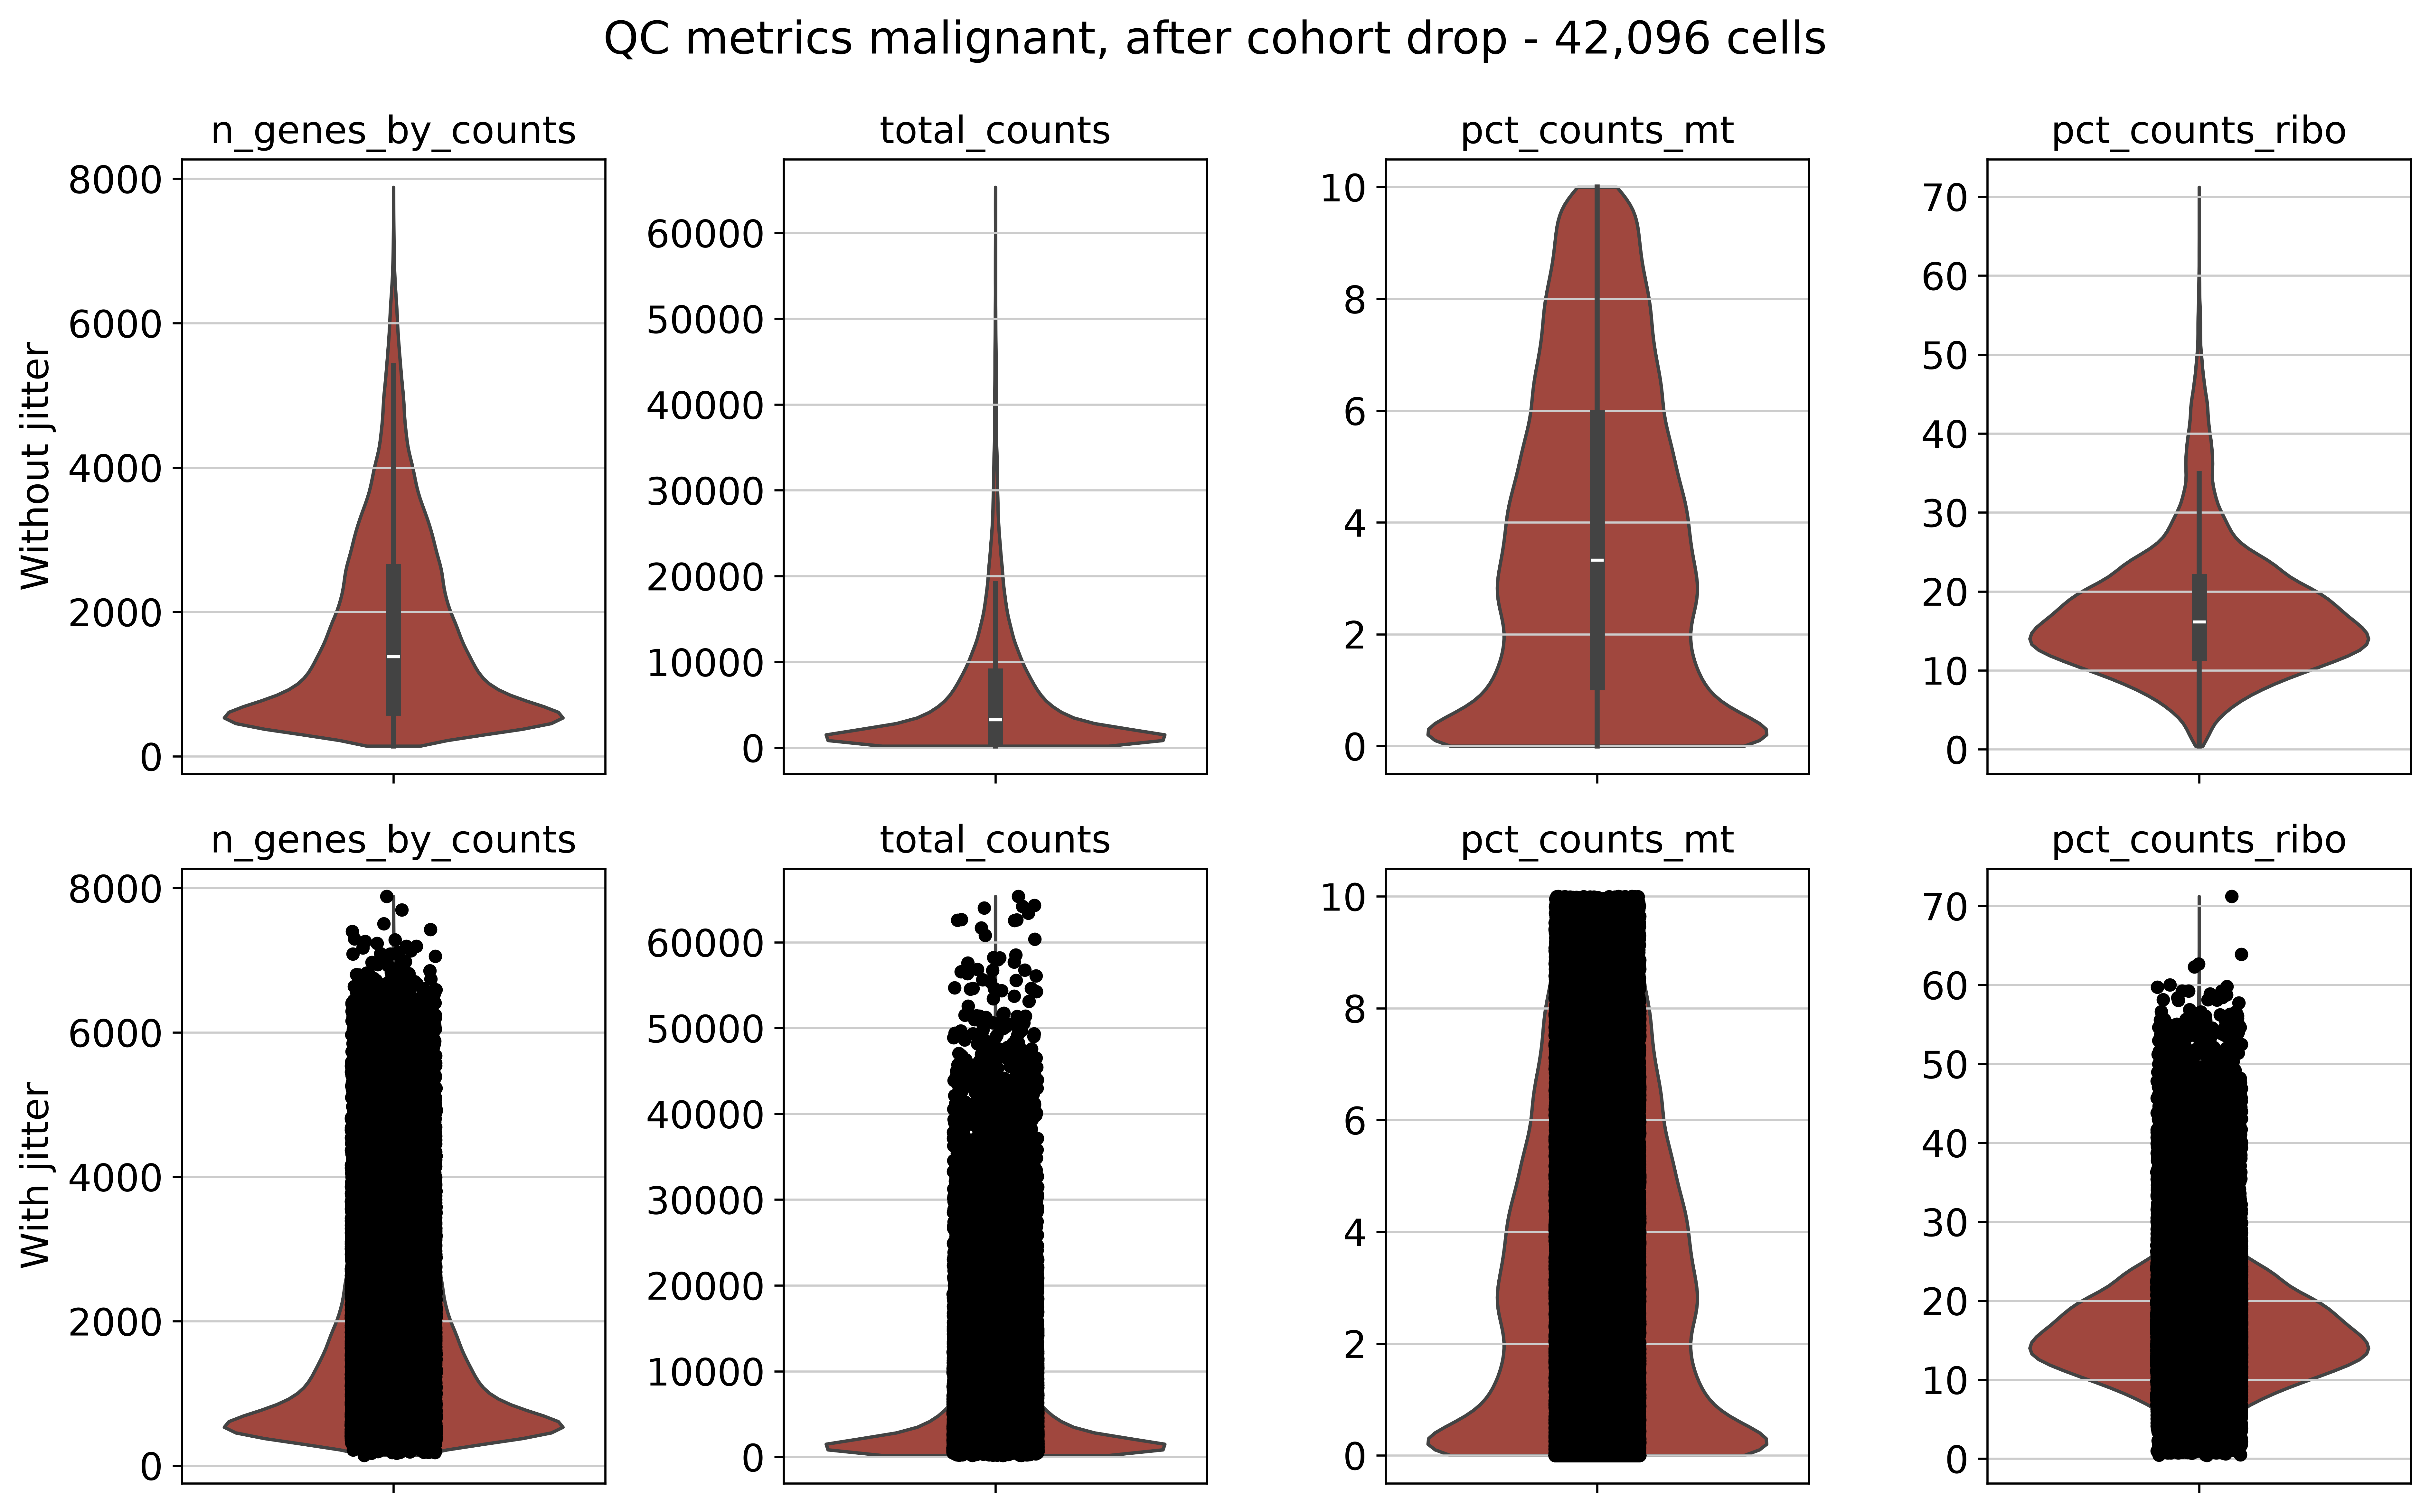

In [27]:
if len(to_drop):
    violin_qc(sub.obs, 'after_cohort_drop')
else:
    print('no cohort dropped: the round above is already the final one')

## Post-conditions, then write

In [28]:
# Checked before writing rather than discovered by scran an hour later.
counts_values = sub.layers['counts'].data
x_values = sub.X.data
assert np.allclose(x_values, np.round(x_values)), '.X must hold raw integer counts'
assert np.array_equal(x_values, counts_values), ".X and layers['counts'] must be identical here"
assert int(np.asarray(sub.X.sum(axis=0) == 0).sum()) == 0, 'zero-count genes left; scran would fail'
assert 'size_factors' not in sub.obs, 'the phase-01 size factors are still here'
assert not sub.obsm and not sub.varm and not sub.obsp, 'a derived slot survived'

assert sub.obs[C.COMPARTMENT_KEY].nunique() == 1, 'the compartment column is not constant'
assert sub.obs['fraction'].nunique() == 1, 'the subset spans both fractions'
assert sub.obs[C.BATCH_KEY].value_counts().min() >= C.MIN_CELLS_PER_COHORT, \
    f'a cohort under {C.MIN_CELLS_PER_COHORT} cells survived'
assert (sub.obs[C.STATUS_KEY] != 'not_tested').all(), 'an untested cell survived the subset'

if C.cell_set() == 'tum':
    assert (sub.obs[C.STATUS_KEY] == 'malignant').all(), 'a non-malignant cell survived'
    assert sub.obs[C.LABEL_KEY].nunique() == 1, \
        'cell_type should be the constant malignant label on this subset'
    # The pre-CNV label is what clustering_tum.py falls back to; it must be usable.
    assert sub.obs[C.PRIOR_LABEL_KEY].nunique() > 1, \
        'the pre-CNV label is constant too: clustering_tum.py would have no NMI target'
else:
    assert set(sub.obs[C.LABEL_KEY].astype(str)) <= (C.EPITHELIAL_CELL_TYPES | {C.MALIGNANT_LABEL}), \
        'a non-epithelial post-CNV label survived the subset'

if C.DROP_INCOMPLETE_COHORTS:
    final_table = pd.crosstab(sub.obs[C.BATCH_KEY], sub.obs[C.TREATMENT_KEY]).reindex(
        columns=list(C.REQUIRED_TREATMENTS), fill_value=0)
    assert not (final_table == 0).any().any(), 'cohorts still missing a timepoint'

print('All post-conditions passed.')
print(f'{C.LABEL_KEY}: {sub.obs[C.LABEL_KEY].nunique()} level(s) | '
      f'{C.PRIOR_LABEL_KEY}: {sub.obs[C.PRIOR_LABEL_KEY].nunique()} level(s)')

All post-conditions passed.
cell_type: 1 level(s) | cell_type_01_4: 10 level(s)


## Saving dataset

`shiao.h5ad` was written by a pandas-3 stack, so its `obs`/`var` indices (the cell barcodes and the
gene symbols) come back as pandas `StringArray`s. anndata refuses to write those by default, because
no reader older than 0.11 understands them - which is a real constraint here: DRVI and scGen live in
environments pinned to older anndata. `02_integration_benchmark/utils/h5ad_compat.py` already solves
this: it downcasts the indices and the extension-dtype columns to plain object arrays and then
re-opens the file to check what actually landed on disk.

Doing it once, here at the head of the chain, is enough - every later step writes an object read
back from this file. Note that this notebook *does* add string columns (`cell_type_01_4`,
`celltypist_predicted_cnv`, the post-CNV `cell_type`), which is exactly what the sanitizer is for.

In [29]:
sys.path.insert(0, os.path.join(REPO_ROOT, '02_integration_benchmark', 'utils'))
from h5ad_compat import write_h5ad_compat

write_h5ad_compat(sub, OUTPUT_H5AD, compression='gzip')
print(f'Wrote {OUTPUT_H5AD} '
      f'({sub.n_obs:,} cells x {sub.n_vars:,} genes, '
      f'{os.path.getsize(OUTPUT_H5AD) / 1024 ** 3:.2f} GB on disk)')
sub

[h5ad_compat] 4 dtype adjustments before writing:


    obs.index -> object


    obs['predicted_doublet'] boolean -> numpy


    var.index -> object


    var['gene_ids'] string -> object


[h5ad_compat] wrote /home/albertoc/Desktop/QCB-Master-Thesis/datasets/05_tum/shiao_tum_raw.h5ad, readable by anndata >=0.7


['obs.index -> object',
 "obs['predicted_doublet'] boolean -> numpy",
 'var.index -> object',
 "var['gene_ids'] string -> object"]

Wrote /home/albertoc/Desktop/QCB-Master-Thesis/datasets/05_tum/shiao_tum_raw.h5ad (42,096 cells x 25,133 genes, 0.33 GB on disk)


AnnData object with n_obs × n_vars = 42096 × 25133
    obs: 'sample', 'batch', 'cohort', 'treatment', 'fraction', 'dataset_origin', 'response', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'is_doublet_shiao', 'high_umi_doublet', 'cell_type', 'celltypist_predicted', 'cnv_status', 'cnv_score', 'cnv_corr', 'cell_type_01_4', 'celltypist_predicted_cnv', 'compartment'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: 'counts', None (.X)

## Next

```bash
export DATA_DIR=~/Desktop/QCB-Master-Thesis/datasets
cd 05_drvi_tumoral_epi/05_2_subsetting
./subsetting_all.sh
```

which produces `shiao_tum.h5ad` (definitive) and `shiao_tum_hvg_2k.h5ad` (the DRVI input for 05_3).
Then inspect the result with `visualization_tum.ipynb`.

To run the control set instead, set `CELL_SET=epi` at the top of this notebook, re-run it, and then
`CELL_SET=epi ./subsetting_all.sh`. Nothing of the `tum` chain is overwritten.